# 03 — Context and Comparison

> **"A number without context is just a number. A number with a benchmark is an insight."**

---

Dữ liệu không có ý nghĩa tuyệt đối — ý nghĩa đến từ **so sánh**.

- 6% tăng trưởng là tốt hay xấu? → Cần biết target, industry average, hay historical baseline.
- Revenue $10M là cao hay thấp? → Cần so sánh với cùng kỳ năm trước, với đối thủ, với kế hoạch.

**Context Injection** là kỹ thuật nhúng điểm tham chiếu trực tiếp vào chart để số liệu tự nói lên ý nghĩa của nó.

### Nội dung notebook này:

1. **Reference Lines** — Mean, median, và custom threshold
2. **Target Lines & Zones** — So sánh actual vs goal
3. **Benchmark Bands** — Industry range / acceptable zone
4. **Excess & Deficit** — Tô màu phần vượt / thiếu so với baseline
5. **Before vs After** — So sánh hai trạng thái trực tiếp
6. **Relative Performance** — Index về cùng base = 100
7. **Distribution Comparison** — KDE overlaid và ridge plot
8. **Small Multiples** — Faceted comparison grid

## Setup

In [1]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

matplotlib.use('Agg')
%matplotlib inline

import sys, os
sys.path.insert(0, os.path.abspath('../src'))

from vizint.core import ChartBuilder, despine, set_grid, make_grid
from vizint.context import (
    add_reference_line,
    add_mean_line,
    add_median_line,
    add_benchmark_band,
    shade_above_benchmark,
    shade_below_benchmark,
    add_target_line,
    add_target_zone,
    shade_excess,
    shade_deficit,
)
from vizint.comparison import (
    compare_lines,
    before_after_lines,
    compare_distributions,
    ridge_plot,
    relative_performance_chart,
    small_multiples,
)
from vizint.annotation import label_last_point, add_note, add_caption
from vizint.core.axes_utils import format_thousands, format_percent

np.random.seed(2024)
print('Setup OK ✓')

Setup OK ✓


## Synthetic Data

Tạo 3 tập dữ liệu:
1. **Monthly revenue** — 1 công ty, 36 tháng, với target và benchmark
2. **Stock prices** — 5 công ty, 60 tháng, để so sánh relative performance
3. **Score distributions** — 4 nhóm, để so sánh distribution

In [2]:
# --- Dataset 1: Monthly Revenue ---
T = 36
months = np.arange(T)

revenue = (
    800
    + np.linspace(0, 200, T)          # uptrend
    + 40 * np.sin(2 * np.pi * months / 12)  # seasonality
    + np.random.randn(T) * 25          # noise
)

TARGET    = 950     # monthly revenue target
BENCHMARK_LOW  = 820
BENCHMARK_HIGH = 920

month_labels = [
    f"{'JFMAMJJASOND'[i % 12]}" for i in range(T)
]

# --- Dataset 2: Stock Prices (5 companies, 60 months) ---
T2 = 60
t2 = np.arange(T2)
stocks = {
    'Alpha':   100 + np.cumsum(np.random.randn(T2) * 1.8 + 0.4),
    'Beta':    100 + np.cumsum(np.random.randn(T2) * 2.1 + 0.2),
    'Gamma':   100 + np.cumsum(np.random.randn(T2) * 1.5 + 0.6),
    'Delta':   100 + np.cumsum(np.random.randn(T2) * 2.5 - 0.1),
    'Epsilon': 100 + np.cumsum(np.random.randn(T2) * 1.2 + 0.3),
}

# --- Dataset 3: Score distributions (4 groups) ---
score_groups = {
    'Group A (Control)':  np.random.normal(72, 8,  200),
    'Group B (Treatment 1)': np.random.normal(78, 7,  200),
    'Group C (Treatment 2)': np.random.normal(82, 10, 200),
    'Group D (Elite)':    np.random.normal(88, 6,  200),
}

print(f'Revenue range : [{revenue.min():.0f}, {revenue.max():.0f}]')
print(f'Stocks        : {list(stocks.keys())}')
print(f'Score groups  : {list(score_groups.keys())}')

Revenue range : [769, 1002]
Stocks        : ['Alpha', 'Beta', 'Gamma', 'Delta', 'Epsilon']
Score groups  : ['Group A (Control)', 'Group B (Treatment 1)', 'Group C (Treatment 2)', 'Group D (Elite)']


## 1. Reference Lines — Mean, Median, Custom

**Reference line** là đường ngang hoặc dọc dùng để đánh dấu một **ngưỡng tham chiếu** trên biểu đồ.
Nó giúp trả lời câu hỏi:

> "So với mức này, dữ liệu đang ở đâu?"

Các loại phổ biến:

* `add_mean_line()` — vẽ đường **mean**
* `add_median_line()` — vẽ đường **median**
* `add_reference_line(value)` — vẽ **custom threshold**
* `add_reference_line(x=...)` — vertical reference line

---

# Mean vs Median — khác nhau thế nào?

## Mean (trung bình cộng)

$$
\text{mean} = \frac{1}{n} \sum x_i
$$

Đặc điểm:

* sử dụng **tất cả giá trị**
* nhạy với **outliers**
* phù hợp distribution **symmetric**
* phản ánh **expected value**

Ví dụ:

```
data = [1, 2, 3, 4, 5]
mean = 3
median = 3
```

Không có vấn đề.

---

## Khi có outlier

```
data = [1, 2, 3, 4, 100]

mean   = 22
median = 3
```

Mean bị kéo lệch mạnh bởi outlier.

Visualization:

```
1  2  3  4                  100
      ↑median         ↑mean
```

→ Mean **không còn đại diện typical value**

---

## Median (trung vị)

Median = giá trị đứng giữa khi sort

Đặc điểm:

* **robust với outlier**
* phù hợp **skewed distribution**
* phản ánh **typical value**
* tốt cho dashboard thực tế

---

# Khi nào dùng Mean vs Median

## Dùng Mean khi

* distribution symmetric
* Gaussian noise
* không có outliers lớn
* scientific measurement
* error analysis

Ví dụ:

* sensor noise
* measurement error
* model residuals

---

## Dùng Median khi

* distribution skewed
* có outliers
* financial data
* business metrics
* latency metrics
* income distribution

Ví dụ:

* salary
* response time
* stock returns
* revenue per user

---

# Mean vs Median như indicator skewness

Khoảng cách giữa mean và median cho biết **độ lệch phân phối**

```
mean > median  → right skew
mean < median  → left skew
mean ≈ median  → symmetric
```

Visualization:

Right skew:

```
median ─────
mean   ───────────
```

Left skew:

```
mean   ─────
median ───────────
```

---

# Custom Reference Lines

Không phải lúc nào cũng mean/median.

Ta thường cần:

### Zero baseline

```
add_reference_line(0)
```

Dùng cho:

* returns
* residuals
* PnL
* change

---

### Target line

```
add_reference_line(target)
```

Dùng cho:

* KPI
* goal
* forecast
* threshold

---

### Previous value

```
add_reference_line(prev_value)
```

Dùng để so sánh:

* previous period
* baseline
* benchmark

---

### Regulatory / Risk limit

```
add_reference_line(limit)
```

Ví dụ:

* VaR threshold
* safety limit
* tolerance band

---

# Horizontal vs Vertical Reference Lines

## Horizontal line

Đánh dấu **value threshold**

```
y = constant
```

Ví dụ:

* mean
* median
* target
* zero

---

## Vertical line

Đánh dấu **time / event**

```
x = constant
```

Ví dụ:

* regime change
* event date
* anomaly start
* intervention

---

# Best Practice

## 1. Luôn dùng median khi unsure

Median an toàn hơn mean.

---

## 2. Vẽ cả mean + median để hiểu distribution

```
mean   ─────────────
median ───────
```

Khoảng cách = skewness

---

## 3. Dùng dashed style cho reference line

Để không cạnh tranh với data

```
linestyle="--"
alpha=0.6
```

---

## 4. Label rõ ràng

Không label = người xem không hiểu

```
Mean = 2.34
Median = 1.98
Target = 3.0
```

---

## 5. Không vẽ quá nhiều lines

Quá nhiều reference → clutter

Chỉ nên:

* mean + median
* hoặc target
* hoặc zero

---

# Visualization Example

```
value
 ^
 |
 |        /\
 |       /  \
 |------/----\-----------  mean
 |     /      \
 |    /        \
 |---/----------\--------  median
 |
 +------------------------------> time
```

---

# Use Cases

## Time series analysis

* mean line → long-term average
* median line → robust baseline
* zero line → change detection

---

## Distribution plots

* histogram mean
* histogram median
* quartile lines

---

## Financial charts

* zero line (PnL)
* VaR threshold
* mean return

---

## ML diagnostics

* residual mean
* error threshold
* decision boundary

---

# Summary

Reference lines giúp:

* hiểu vị trí data
* phát hiện shift
* detect outliers
* so sánh baseline
* highlight threshold

Mean vs Median:

* Mean → symmetric data
* Median → robust / skewed data
* Mean + Median → detect skewness


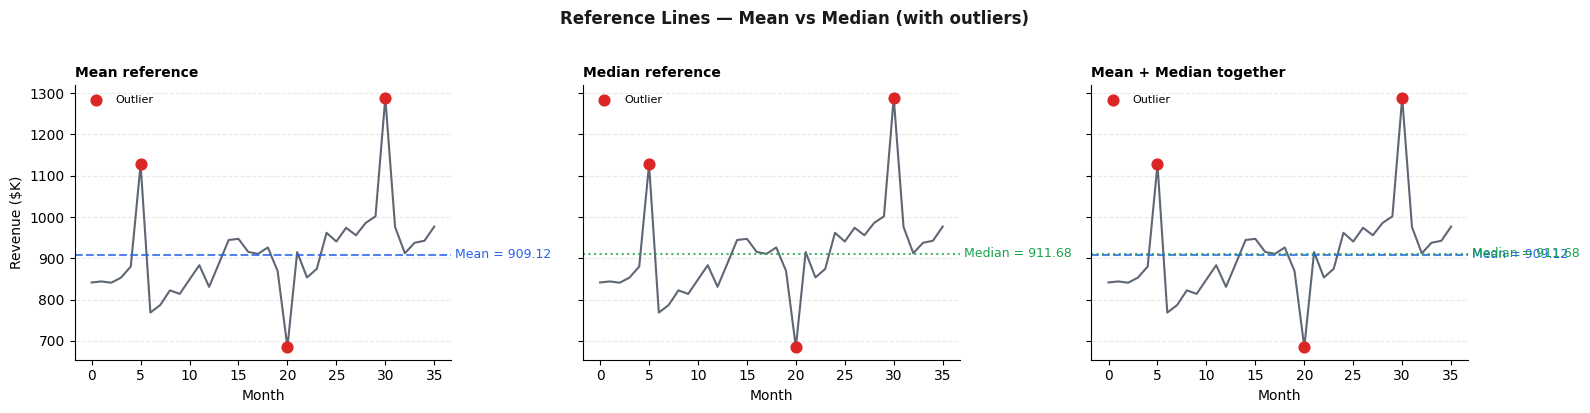

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4), facecolor='white', sharey=True)

# Tạo series có outlier để thấy rõ mean vs median
revenue_with_spike = revenue.copy()
revenue_with_spike[[5, 20, 30]] += np.array([250, -200, 300])  # inject outliers

titles = ['Mean reference', 'Median reference', 'Mean + Median together']

for i, (ax, title) in enumerate(zip(axes, titles)):
    ax.plot(months, revenue_with_spike, color='#374151', linewidth=1.5, alpha=0.8)
    ax.scatter([5, 20, 30], revenue_with_spike[[5, 20, 30]],
               color='#DC2626', s=60, zorder=5, label='Outlier')

    if i == 0 or i == 2:
        add_mean_line(ax, revenue_with_spike, color='#2563EB',
                      linewidth=1.5, show_label=True)
    if i == 1 or i == 2:
        add_median_line(ax, revenue_with_spike, color='#16A34A',
                        linewidth=1.5, show_label=True)

    ax.set_title(title, loc='left', fontsize=10, fontweight='bold')
    ax.set_xlabel('Month')
    if i == 0:
        ax.set_ylabel('Revenue ($K)')
    ax.legend(frameon=False, fontsize=8)
    despine(ax); set_grid(ax)

fig.suptitle('Reference Lines — Mean vs Median (with outliers)',
             fontsize=12, fontweight='bold', color='#1a1a1a', y=1.02)
plt.tight_layout()
plt.show()

## Insights — Mean vs Median Reference Lines (with Outliers)

Biểu đồ so sánh 3 trường hợp:

* Mean reference
* Median reference
* Mean + Median together

Dữ liệu có 2 outliers:

* spike cao ≈ 1300
* drop thấp ≈ 680

---

# 1. Outliers kéo Mean mạnh hơn Median

Mean:

$$
\mu = 909.12
$$

Median:

$$
\text{median} = 911.68
$$

Ta thấy:

$$
\mu < \text{median}
$$

→ Mean bị kéo xuống bởi **outlier thấp**

Median gần trung tâm hơn → **robust hơn**

---

# 2. Distribution hơi lệch trái (left-skewed)

Quy tắc:

$$
\mu < \text{median}
\Rightarrow
\text{left skew}
$$

Nguyên nhân:

* drop mạnh tại month ≈ 20
* tail bên trái dài hơn
* mean bị kéo xuống

Median không bị ảnh hưởng nhiều.

---

# 3. Mean bị bias bởi magnitude của outliers

Mean phụ thuộc:

$$
\mu = \frac{1}{n}\sum x_i
$$

→ magnitude lớn → ảnh hưởng lớn

Hai điểm:

* $x \approx 1300$
* $x \approx 680$

đều kéo mean.

Median chỉ phụ thuộc **rank**:

$$
\text{median} = x_{(n+1)/2}
$$

→ không phụ thuộc magnitude

---

# 4. Median phản ánh "typical value" tốt hơn

Phần lớn dữ liệu nằm trong khoảng:

$$
900 \sim 980
$$

Median:

$$
\text{median} \approx 912
$$

Mean:

$$
\mu \approx 909
$$

Median nằm gần trung tâm cluster hơn.

---

# 5. Mean + Median together → reveal skewness

Panel 3:

* hai đường gần nhau
* nhưng không trùng nhau
* median cao hơn mean

$$
|\mu - \text{median}| \approx 2.56
$$

→ skew nhẹ
→ outliers tồn tại nhưng không cực đoan

---

# 6. Median là baseline tốt hơn cho time series

Median:

* ổn định hơn
* ít bị spike ảnh hưởng
* baseline tốt hơn
* ít false anomaly

Mean:

* bị shift bởi spike
* baseline không ổn định
* dễ tạo false signal

---

# 7. Practical Interpretation

Nếu dùng reference line để:

### anomaly detection

Dùng median tốt hơn

### regime shift detection

Median ổn định hơn

### financial data

Median robust hơn

### symmetric noise

Mean phù hợp hơn

---

# 8. Visual Interpretation

Dữ liệu:

* cluster quanh 900–980
* 1 spike lớn
* 1 drop lớn

Do đó:

$$
\text{median} > \mu
$$

→ tail trái nặng hơn

---

# 9. Key Takeaways

* Mean nhạy với outliers
* Median robust hơn
* Mean < Median → left skew
* Mean + Median → reveal skewness
* Median tốt hơn cho baseline
* Mean tốt hơn cho symmetric data

---

# 10. Summary

Reference lines:

Mean:

$$
y = \mu
$$

Median:

$$
y = Q_{0.5}
$$

Skewness indicator:

$$
\mu > Q_{0.5} \Rightarrow \text{right skew}
$$

$$
\mu < Q_{0.5} \Rightarrow \text{left skew}
$$

Trong biểu đồ này:

$$
\mu < \text{median}
\Rightarrow
\text{slight left skew}
$$


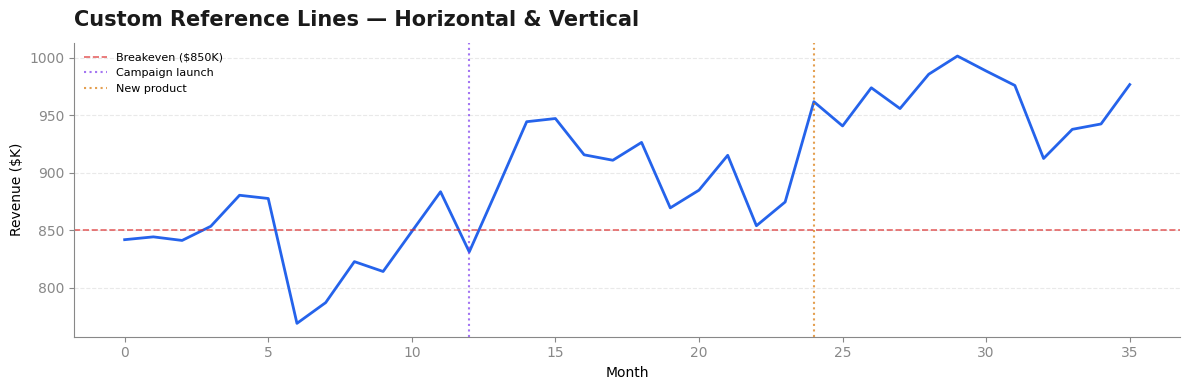

In [4]:
# Custom reference lines — vertical + horizontal kết hợp
chart = (
    ChartBuilder(figsize=(12, 4))
    .set_title('Custom Reference Lines — Horizontal & Vertical')
    .build()
)
ax = chart.ax

ax.plot(months, revenue, color='#2563EB', linewidth=2.0)

# Horizontal: breakeven threshold
add_reference_line(ax, value=850, orientation='h',
                   color='#DC2626', linestyle='--', linewidth=1.2,
                   label='Breakeven ($850K)')

# Vertical: campaign launch at month 12
add_reference_line(ax, value=12, orientation='v',
                   color='#7C3AED', linestyle=':', linewidth=1.5,
                   label='Campaign launch')

# Vertical: new product at month 24
add_reference_line(ax, value=24, orientation='v',
                   color='#D97706', linestyle=':', linewidth=1.5,
                   label='New product')

ax.set_xlabel('Month')
ax.set_ylabel('Revenue ($K)')
ax.legend(frameon=False, fontsize=8)

plt.tight_layout()
plt.show()

## Insights — Custom Reference Lines (Horizontal & Vertical)

Biểu đồ sử dụng 3 **custom reference lines**:

* Horizontal: Breakeven = $850K
* Vertical: Campaign launch (month ≈ 12)
* Vertical: New product (month ≈ 24)

---

# 1. Breakeven Line — Profitability Threshold

Horizontal reference:

$$
y = 850
$$

Ý nghĩa:

* $y > 850$ → profitable
* $y < 850$ → under breakeven

Quan sát:

* Trước month 10: nhiều điểm dưới breakeven
* Sau month 12: phần lớn nằm trên breakeven

→ doanh thu **ổn định hơn sau campaign**

---

# 2. Campaign Launch — Regime Change

Vertical line:

$$
x = 12
$$

Trước campaign:

$$
\text{Revenue} \approx 770 \sim 880
$$

Sau campaign:

$$
\text{Revenue} \approx 900 \sim 950
$$

→ shift upward rõ ràng

Dấu hiệu:

* mean level tăng
* ít điểm dưới breakeven
* volatility giảm nhẹ

→ campaign **có hiệu quả**

---

# 3. New Product — Second Regime Shift

Vertical line:

$$
x = 24
$$

Sau month 24:

$$
\text{Revenue} \approx 940 \sim 1000
$$

So với trước đó:

$$
900 \sim 950
$$

→ level shift lần 2

New product tạo:

* tăng level
* tăng peak
* giữ trên breakeven hoàn toàn

---

# 4. Two-Step Growth Pattern

Biểu đồ cho thấy **2 regime shifts**:

Step 1 — Campaign:

$$
\mu_1 \rightarrow \mu_2
$$

Step 2 — New product:

$$
\mu_2 \rightarrow \mu_3
$$

Với:

$$
\mu_1 < \mu_2 < \mu_3
$$

→ tăng trưởng theo **phases**

---

# 5. Breakeven Crossing Analysis

Trước campaign:

$$
P(y > 850) \text{ thấp}
$$

Sau campaign:

$$
P(y > 850) \text{ tăng mạnh}
$$

Sau new product:

$$
P(y > 850) \approx 1
$$

→ risk giảm theo thời gian

---

# 6. Structural Change Interpretation

Reference lines giúp nhìn thấy:

* event timing
* level shift
* threshold crossing
* regime change

Cấu trúc:

```
Phase 1: pre-campaign
Phase 2: post-campaign
Phase 3: post-product
```

---

# 7. Visual Story

Month 0–12:

* dưới breakeven nhiều
* volatility cao
* growth yếu

Month 12–24:

* vượt breakeven ổn định
* level tăng
* trend upward

Month 24–36:

* level cao hơn
* peak ~1000
* growth mạnh hơn

---

# 8. Business Interpretation

Campaign launch:

* cải thiện demand
* tăng awareness
* lift revenue

New product:

* mở rộng market
* tăng ARPU
* tăng peak revenue

---

# 9. Mathematical Representation

Piecewise level:

$$
y_t =
\begin{cases}
\mu_1 + \epsilon_t & t < 12 \\
\mu_2 + \epsilon_t & 12 \le t < 24 \\
\mu_3 + \epsilon_t & t \ge 24
\end{cases}
$$

Với:

$$
\mu_1 < \mu_2 < \mu_3
$$

---

# 10. Key Takeaways

* Horizontal line → threshold
* Vertical line → events
* Campaign → level shift
* Product → second shift
* Breakeven → profitability view
* Reference lines → reveal regime changes


## 2. Target Lines & Target Zones

**Target line** là một **ngưỡng cứng** phải đạt được (KPI, quota, SLA).
**Target zone** là một **khoảng chấp nhận được** thay vì một giá trị duy nhất.

Khác biệt chính:

* Target line → pass / fail rõ ràng
* Target zone → acceptable range
* Target line → strict KPI
* Target zone → tolerance-based KPI

---

### 2.1. Target Line

Target line là một reference line:

$$
y = y_{\text{target}}
$$

Decision rule:

$$
y_t \ge y_{\text{target}} \Rightarrow \text{achieved}
$$

$$
y_t < y_{\text{target}} \Rightarrow \text{not achieved}
$$

Ví dụ:

* revenue target: $900K
* SLA latency: 200ms
* accuracy target: 0.95

Visualization:

```
target  ─────────────
data        /\
           /  \__
```

---

### 2.2. Target Zone

Target zone là một **interval**:

$$
y_{\min} \le y_t \le y_{\max}
$$

Hoặc:

$$
y_t \in [y_{\min}, y_{\max}]
$$

Decision rule:

Inside zone:

$$
y_{\min} \le y_t \le y_{\max}
$$

Outside zone:

$$
y_t < y_{\min}
\quad \text{or} \quad
y_t > y_{\max}
$$

---

### 2.3. Ví dụ thực tế

### Inflation target

$$
2% \le \pi_t \le 4%
$$

Không cần đúng 3% — chỉ cần nằm trong range.

---

### Blood pressure

$$
80 \le BP \le 120
$$

Không cần đúng 100.

---

### Inventory level

$$
500 \le I_t \le 1500
$$

Quá thấp → stockout
Quá cao → holding cost

---

### 2.4. Target Zone Visualization

Target zone thường hiển thị bằng:

* shaded band
* fill_between
* background region

Mathematical region:

$$
\text{zone} =
{ y : y_{\min} \le y \le y_{\max} }
$$

Visualization:

```
upper ─────────────
     ██████████████
     █   target    █
     █    zone     █
lower ─────────────
```

---

### 2.5. Target Line vs Target Zone

### Target line

$$
y = c
$$

Binary decision:

* pass
* fail

---

### Target zone

$$
c_1 \le y \le c_2
$$

Three-state decision:

* below target
* within target
* above target

---

### 2.6. Three-State Classification

Given:

$$
y_{\min}, y_{\max}
$$

Classification:

Below:

$$
y_t < y_{\min}
$$

Within:

$$
y_{\min} \le y_t \le y_{\max}
$$

Above:

$$
y_t > y_{\max}
$$

---

### 2.7. Deviation from Target Zone

Distance to zone:

Below deviation:

$$
d_t = y_{\min} - y_t
$$

Above deviation:

$$
d_t = y_t - y_{\max}
$$

Inside zone:

$$
d_t = 0
$$

---

### 2.8. Target Center Line

Target zone thường có **center target**:

$$
y_c = \frac{y_{\min} + y_{\max}}{2}
$$

Cho biết:

* optimal value
* preferred level

---

### 2.9. Soft vs Hard Targets

### Hard target

$$
y \ge c
$$

strict.

---

### Soft target

$$
c_1 \le y \le c_2
$$

tolerant.

---

### 2.10. Time Series Interpretation

Target zone giúp thấy:

* stability
* drift
* volatility
* compliance

Nếu data nằm trong zone:

→ stable system

Nếu oscillate quanh zone:

→ borderline system

Nếu drift ra ngoài:

→ regime change

---

### 2.11. KPI Compliance Rate

Compliance rate:

$$
\text{compliance}
=================

\frac{
\sum \mathbf{1}
(y_{\min} \le y_t \le y_{\max})
}{T}
$$

Cho biết:

* % thời gian đạt target
* reliability

---

### 2.12. Overshoot / Undershoot

Overshoot:

$$
y_t > y_{\max}
$$

Undershoot:

$$
y_t < y_{\min}
$$

Magnitude:

$$
\text{overshoot} = y_t - y_{\max}
$$

$$
\text{undershoot} = y_{\min} - y_t
$$

---

### 2.13. Visualization Best Practice

Nên vẽ:

* zone shading
* upper line
* lower line
* center line (optional)

```
upper   ─────────────
        █████████████
center  ─────────────
        █████████████
lower   ─────────────
```

---

### 2.14. Combined with Target Line

Có thể dùng:

* target zone (acceptable)
* target line (goal)

Ví dụ:

$$
850 \le y_t \le 950
$$

Preferred:

$$
y = 900
$$

---

### 2.15. Use Cases

Target zone phù hợp cho:

* KPI tolerance
* control systems
* finance bands
* medical ranges
* inventory management
* SLA monitoring

---

### 2.16. Summary

Target line:

$$
y = y_{\text{target}}
$$

Target zone:

$$
y_{\min} \le y \le y_{\max}
$$

Classification:

$$
\text{below}
\quad
\text{within}
\quad
\text{above}
$$

Target zone giúp:

* hiểu acceptable range
* đo compliance
* detect drift
* visualize stability
* giảm binary thinking


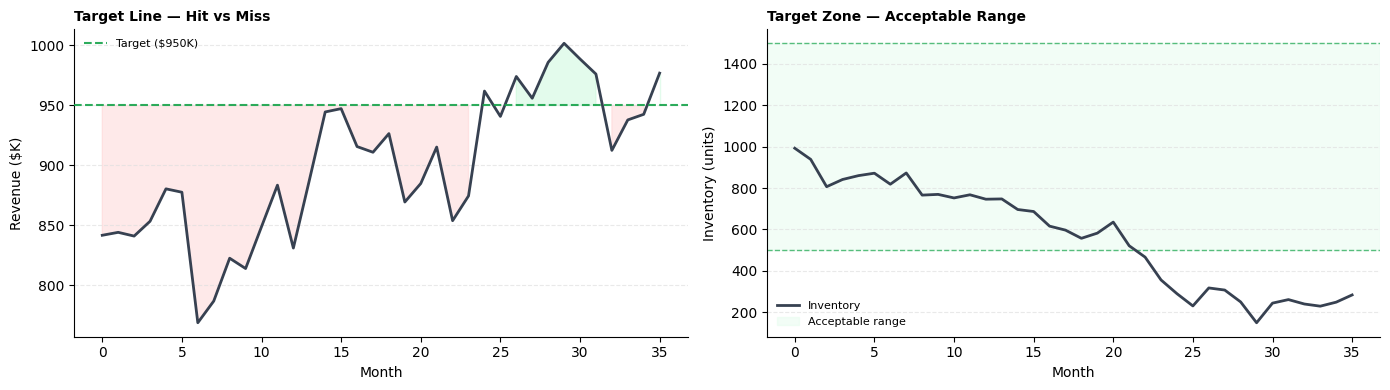

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4), facecolor='white')

# Panel 1: Target line + above/below shading
ax = axes[0]
ax.plot(months, revenue, color='#374151', linewidth=2.0)
add_target_line(ax, TARGET, color='#16A34A', linewidth=1.5,
                linestyle='--', label=f'Target (${TARGET}K)')

# Shade above (met target) and below (missed target)
shade_above_benchmark(ax, months, revenue, TARGET,
                      color='#BBF7D0', alpha=0.4)
shade_below_benchmark(ax, months, revenue, TARGET,
                      color='#FECACA', alpha=0.4)

ax.set_title('Target Line — Hit vs Miss', loc='left', fontsize=10, fontweight='bold')
ax.set_xlabel('Month'); ax.set_ylabel('Revenue ($K)')
ax.legend(frameon=False, fontsize=8)
despine(ax); set_grid(ax)

# Panel 2: Target zone
ax = axes[1]

# Simulate inventory level
inventory = 1000 + np.cumsum(np.random.randn(T) * 60)
ax.plot(months, inventory, color='#374151', linewidth=2.0, label='Inventory')
add_target_zone(ax, lower=500, upper=1500,
                color='#DCFCE7', alpha=0.35,
                border_color='#16A34A', border_style='--',
                label='Acceptable range')

ax.set_title('Target Zone — Acceptable Range', loc='left', fontsize=10, fontweight='bold')
ax.set_xlabel('Month'); ax.set_ylabel('Inventory (units)')
ax.legend(frameon=False, fontsize=8)
despine(ax); set_grid(ax)

plt.tight_layout()
plt.show()

## Insights — Target Line vs Target Zone

Biểu đồ gồm 2 phần:

* Left: **Target Line — Hit vs Miss**
* Right: **Target Zone — Acceptable Range**

---

# 1. Target Line — Binary KPI (Hit / Miss)

Target:

$$
y_{\text{target}} = 950
$$

Decision rule:

$$
y_t \ge 950 \Rightarrow \text{Hit}
$$

$$
y_t < 950 \Rightarrow \text{Miss}
$$

Quan sát:

* Month 0–14: mostly **miss**
* Month 15–18: gần target
* Month 24–31: **hit liên tục**
* Month 32: drop → miss
* Month 33–36: recovery

→ KPI chỉ đạt ở **giai đoạn cuối**

---

# 2. Regime Shift Toward Target

Trước month 24:

$$
y_t < 950 \quad \text{(mostly)}
$$

Sau month 24:

$$
y_t \ge 950 \quad \text{(frequent)}
$$

→ level shift upward

Target line giúp nhìn thấy:

* thời điểm bắt đầu đạt KPI
* stability sau khi đạt
* drop dưới target

---

# 3. Compliance Rate

Compliance:

$$\text{Compliance} = \frac{\sum \mathbf{1}(y_t \ge 950)}{T}$$
Rough estimate:

* early period: ~0%
* late period: ~70–80%

→ KPI chỉ đạt **late stage**

---

# 4. Target Zone — Acceptable Range

Zone:

$$
500 \le I_t \le 1500
$$

Interpretation:

* within → acceptable
* below → shortage
* above → overstock

---

# 5. Inventory Drift Downward

Quan sát:

* Month 0: ~1000
* Month 15: ~700
* Month 20: ~600
* Month 25: ~300
* Month 29: ~150

Trend:

$$
I_t \downarrow
$$

→ inventory depletion

---

# 6. Zone Violation

Zone lower bound:

$$
I_{\min} = 500
$$

Sau month ~22:

$$
I_t < 500
$$

→ liên tục **vi phạm target zone**

Hệ quả:

* stockout risk
* demand unmet
* supply issue

---

# 7. Three-State Interpretation

Target zone tạo 3 trạng thái:

Above:

$$
I_t > 1500
$$

Within:

$$
500 \le I_t \le 1500
$$

Below:

$$
I_t < 500
$$

Trong biểu đồ:

* early: within zone
* mid: borderline
* late: below zone

---

# 8. Stability vs Degradation

Early period:

$$
I_t \in [500,1500]
$$

System stable.

Late period:

$$
I_t < 500
$$

System unstable.

→ degradation theo thời gian

---

# 9. Target Line vs Target Zone

Target line:

$$
y = 950
$$

Binary:

* hit
* miss

---

Target zone:

$$
500 \le y \le 1500
$$

Ternary:

* below
* within
* above

---

# 10. When to Use

Target line:

* sales quota
* KPI
* SLA
* accuracy target

Target zone:

* inventory
* inflation
* temperature
* latency band

---

# 11. Key Takeaways

Target line:

* strict KPI
* binary decision
* detect hit/miss
* show regime shift

Target zone:

* acceptable band
* stability monitoring
* detect drift
* detect violations

---

# 12. Visual Story

Left chart:

* early miss
* gradual improvement
* late hit
* slight volatility

Right chart:

* stable start
* gradual decline
* zone breach
* persistent shortage

→ revenue improves while inventory collapses

---

# 13. Combined Interpretation

Revenue:

$$
\uparrow
$$

Inventory:

$$
\downarrow
$$

→ demand tăng nhưng supply không theo kịp

Possible cause:

* successful campaign
* product demand surge
* insufficient restocking

→ operational bottleneck

---

# 14. Summary

Target line:

$$
y_t \ge y_{\text{target}}
$$

Target zone:

$$
y_{\min} \le y_t \le y_{\max}
$$

Left chart:

* binary KPI tracking

Right chart:

* range-based monitoring

Kết hợp:

* performance + stability
* demand + supply
* hit + risk


## 3. Benchmark Bands

**Benchmark band** là vùng tô màu biểu diễn **khoảng tham chiếu bên ngoài** — thường được xây dựng từ:

* Industry average
* Peer group performance
* Historical normal range
* Market baseline

Ta có thể định nghĩa benchmark band như một khoảng:

$$
[\text{Benchmark}*{low},; \text{Benchmark}*{high}]
$$

Giả sử giá trị quan sát thực tế là:

$$
x_{actual}
$$

---

### Cách diễn giải

So sánh vị trí của $x_{actual}$ với benchmark band:

**1. Nằm trong band (normal)**

$$
\text{Benchmark}*{low} \le x*{actual} \le \text{Benchmark}_{high}
$$

→ Hoạt động trong phạm vi bình thường của thị trường

---

**2. Vượt benchmark (outperform)**

$$
x_{actual} > \text{Benchmark}_{high}
$$

→ Hiệu suất tốt hơn mức trung bình ngành

---

**3. Dưới benchmark (underperform)**

$$
x_{actual} < \text{Benchmark}_{low}
$$

→ Hiệu suất kém hơn mức thị trường

---

### Phân biệt với Target Zone

**Target zone** là mục tiêu nội bộ:

$$
[\text{Target}*{low},; \text{Target}*{high}]
$$

**Benchmark band** là tham chiếu bên ngoài:

$$
[\text{Benchmark}*{low},; \text{Benchmark}*{high}]
$$

Khác biệt:

| Concept        | Source   | Ý nghĩa               |
| -------------- | -------- | --------------------- |
| Target zone    | Internal | Bạn muốn đạt          |
| Benchmark band | External | Thị trường đang ở đâu |

---

### Ví dụ

Benchmark conversion rate:

$$
[2%,;4%]
$$

Nếu:

$$
x_{actual} = 5%
$$

→ outperform benchmark

Nếu:

$$
x_{actual} = 1%
$$

→ underperform benchmark

---

### Ý nghĩa trực quan

Benchmark band giúp trả lời câu hỏi:

> "Giá trị này đang **bất thường so với thị trường** hay không?"

Không phải đúng/sai — mà là **so sánh tương đối với bên ngoài**.


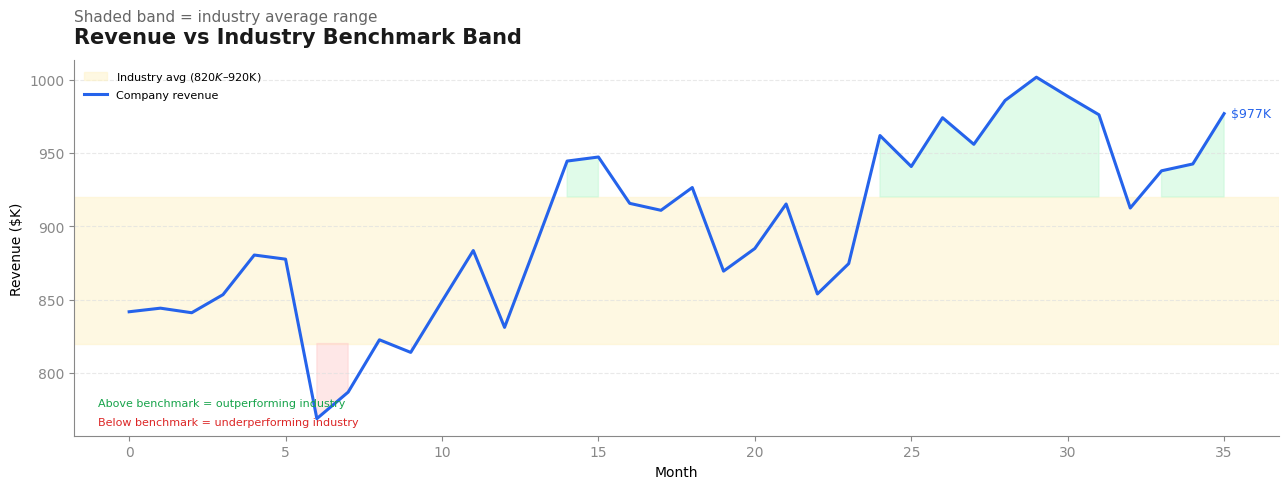

In [6]:
chart = (
    ChartBuilder(figsize=(13, 5))
    .set_title('Revenue vs Industry Benchmark Band')
    .set_subtitle('Shaded band = industry average range')
    .build()
)
ax = chart.ax

# Benchmark band (industry range)
add_benchmark_band(ax, lower=BENCHMARK_LOW, upper=BENCHMARK_HIGH,
                   color='#FEF3C7', alpha=0.5,
                   label=f'Industry avg (${BENCHMARK_LOW}K–${BENCHMARK_HIGH}K)')

# Actual series
ax.plot(months, revenue, color='#2563EB', linewidth=2.2, label='Company revenue', zorder=3)

# Shade khi vượt benchmark (outperformance)
shade_above_benchmark(ax, months, revenue, BENCHMARK_HIGH,
                      color='#BBF7D0', alpha=0.45)
# Shade khi dưới benchmark (underperformance)
shade_below_benchmark(ax, months, revenue, BENCHMARK_LOW,
                      color='#FECACA', alpha=0.45)

# Label điểm cuối
label_last_point(ax, months, revenue,
                 text=f'${revenue[-1]:.0f}K', color='#2563EB')

add_note(ax, 'Above benchmark = outperforming industry',
         x=0.02, y=0.10, color='#16A34A', fontsize=8)
add_note(ax, 'Below benchmark = underperforming industry',
         x=0.02, y=0.05, color='#DC2626', fontsize=8)

ax.set_xlabel('Month'); ax.set_ylabel('Revenue ($K)')
ax.legend(frameon=False, fontsize=8, loc='upper left')

plt.tight_layout()
plt.show()

### Hiệu quả và lợi ích của Benchmark Band

Benchmark band giúp chuyển một line chart thông thường thành **decision chart** — không chỉ thấy tăng/giảm mà còn thấy **tăng/giảm có ý nghĩa hay không**.

Giả sử benchmark band:

$$
[B_{low},; B_{high}]
$$

và giá trị thực tế theo thời gian:

$$
x_t
$$

---

## 1. Biến raw chart thành decision chart

Không có benchmark:

$$
x_t \uparrow \quad \text{hoặc} \quad x_t \downarrow
$$

→ chỉ biết xu hướng

Có benchmark:

$$
x_t ;; \text{vs} ;; [B_{low}, B_{high}]
$$

→ biết **tốt / bình thường / xấu**

---

## 2. Highlight meaningful deviations

Chỉ những điểm vượt band mới được nhấn mạnh:

Outperform:

$$
x_t > B_{high}
$$

Underperform:

$$
x_t < B_{low}
$$

Các điểm nằm trong band:

$$
B_{low} \le x_t \le B_{high}
$$

→ được xem là **normal variation**

Điều này giúp:

* Giảm noise
* Nhấn mạnh signal
* Tránh over-interpretation

---

## 3. So sánh tương đối thay vì tuyệt đối

Cùng một giá trị:

$$
x_t = 900
$$

Benchmark A:

$$
[820,;920]
$$

→ normal

Benchmark B:

$$
[950,;1050]
$$

→ underperform

Do đó benchmark band giúp diễn giải:

$$
\text{performance} = f(x_t,; \text{benchmark})
$$

không chỉ phụ thuộc vào $x_t$.

---

## 4. Phát hiện regime change

Nếu nhiều điểm liên tiếp vượt band:

$$
x_t > B_{high} \quad \text{for many } t
$$

→ không còn là spike

→ trở thành **structural improvement**

Ngược lại:

$$
x_t < B_{low}
$$

liên tục → structural decline

---

## 5. Hỗ trợ storytelling

Không benchmark:

> Revenue increased

Có benchmark:

> Revenue moved from underperform → normal → outperform industry

Benchmark band giúp tạo narrative:

$$
\text{Underperform} \rightarrow \text{Normal} \rightarrow \text{Outperform}
$$

---

## Khi nên dùng Benchmark Band

Dùng khi có baseline bên ngoài:

* Industry average
* Market benchmark
* Peer group
* Historical normal range
* Risk thresholds
* KPI acceptable range

---

## Tóm tắt

Benchmark band trả lời câu hỏi:

$$
\text{Giá trị này có bất thường so với thị trường không?}
$$

không chỉ:

$$
\text{Giá trị này tăng hay giảm?}
$$

Đây là lý do benchmark band giúp **phân biệt signal vs noise** tốt hơn.


## 4. Excess & Deficit Shading

**Excess** là phần giá trị **vượt trên baseline** → thường tô màu xanh.
**Deficit** là phần giá trị **thấp hơn baseline** → thường tô màu đỏ.

Giả sử:

* Chuỗi dữ liệu thực tế:
  $$
  x_t
  $$

* Baseline (chuẩn so sánh):
  $$
  b_t
  $$

Khi đó:

**Excess (positive deviation)**

$$
x_t > b_t
$$

Phần được tô:

$$
\text{Excess}_t = x_t - b_t
$$

---

**Deficit (negative deviation)**

$$
x_t < b_t
$$

Phần được tô:

$$
\text{Deficit}_t = b_t - x_t
$$

---

## Biểu diễn piecewise

Có thể viết gọn bằng hàm:

Excess:

$$
\text{Excess}_t = \max(x_t - b_t,, 0)
$$

Deficit:

$$
\text{Deficit}_t = \max(b_t - x_t,, 0)
$$

Hoặc:

$$
x_t - b_t =
\begin{cases}
\text{Excess} & x_t > b_t \
-\text{Deficit} & x_t < b_t
\end{cases}
$$

---

## Baseline có thể là gì?

### 1. Scalar baseline

Ví dụ:

* Target
* Zero line
* Historical mean

$$
b_t = c
$$

Ví dụ profit vs zero:

$$
b_t = 0
$$

→ tô xanh khi profit > 0
→ tô đỏ khi profit < 0

---

### 2. Dynamic baseline (array)

Baseline thay đổi theo thời gian:

$$
b_t = \text{previous year}_t
$$

hoặc

$$
b_t = \text{budget}_t
$$

hoặc

$$
b_t = \text{peer avg}_t
$$

Khi đó shading thể hiện:

$$
x_t - b_t
$$

→ variance theo thời gian

---

## Ý nghĩa trực quan

Excess/Deficit shading giúp trả lời:

$$
\text{Chúng ta vượt hay thiếu bao nhiêu so với baseline?}
$$

không chỉ:

$$
\text{Đường nào cao hơn?}
$$

---

## Ứng dụng phổ biến

### 1. P&L charts

Profit vs zero:

$$
\text{Profit}_t ; \text{vs} ; 0
$$

* Profit > 0 → xanh
* Loss < 0 → đỏ

---

### 2. Variance analysis

Actual vs Budget:

$$
\text{Variance}_t = \text{Actual}_t - \text{Budget}_t
$$

* Positive variance → xanh
* Negative variance → đỏ

---

### 3. vs Prior Year

So sánh YoY:

$$
x_t - x_{t-1}
$$

* Tăng trưởng → excess
* Giảm → deficit

---

## Ưu điểm

Excess/Deficit shading:

* Nhấn mạnh magnitude deviation
* Hiển thị direction + size cùng lúc
* Tốt hơn line crossover đơn thuần
* Dễ đọc với người không kỹ thuật

---

## Tóm tắt

Excess / Deficit shading trực quan hóa:

$$
x_t - b_t
$$

thành:

* vùng xanh nếu $x_t > b_t$
* vùng đỏ nếu $x_t < b_t$

Giúp biểu diễn **variance trực quan** thay vì chỉ so sánh hai đường.


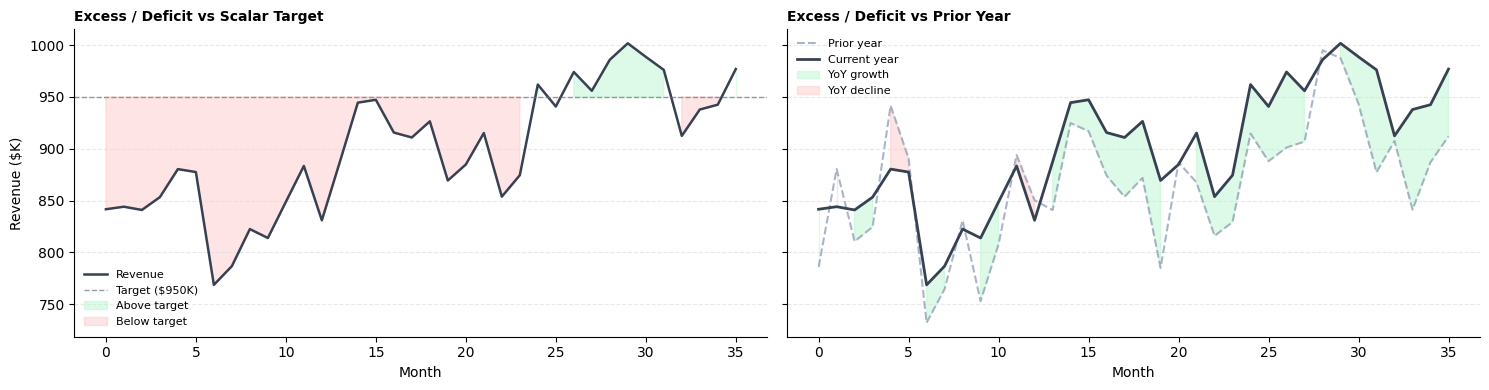

In [7]:
# Prior year revenue (baseline)
prior_year = revenue - np.random.randn(T) * 30 - np.linspace(0, 60, T)

fig, axes = plt.subplots(1, 2, figsize=(15, 4), facecolor='white', sharey=True)

# Panel 1: Excess/deficit vs scalar target
ax = axes[0]
ax.plot(months, revenue, color='#374151', linewidth=1.8, label='Revenue')
ax.axhline(TARGET, color='#6B7280', linewidth=1.0, linestyle='--', alpha=0.7,
           label=f'Target (${TARGET}K)')
shade_excess(ax, months, revenue, baseline=TARGET,
             color='#BBF7D0', alpha=0.5, label='Above target')
shade_deficit(ax, months, revenue, baseline=TARGET,
              color='#FECACA', alpha=0.5, label='Below target')
ax.set_title('Excess / Deficit vs Scalar Target', loc='left', fontsize=10, fontweight='bold')
ax.set_xlabel('Month'); ax.set_ylabel('Revenue ($K)')
ax.legend(frameon=False, fontsize=8)
despine(ax); set_grid(ax)

# Panel 2: Excess/deficit vs prior year (array baseline)
ax = axes[1]
ax.plot(months, prior_year, color='#94A3B8', linewidth=1.5,
        linestyle='--', label='Prior year', alpha=0.8)
ax.plot(months, revenue, color='#374151', linewidth=2.0, label='Current year')
shade_excess(ax, months, revenue, baseline=prior_year,
             color='#BBF7D0', alpha=0.5, label='YoY growth')
shade_deficit(ax, months, revenue, baseline=prior_year,
              color='#FECACA', alpha=0.5, label='YoY decline')
ax.set_title('Excess / Deficit vs Prior Year', loc='left', fontsize=10, fontweight='bold')
ax.set_xlabel('Month')
ax.legend(frameon=False, fontsize=8)
despine(ax); set_grid(ax)

plt.tight_layout()
plt.show()

## Excess & Deficit Shading — Hiệu quả và lợi ích

Excess / Deficit shading trực quan hóa **độ lệch so với baseline** thay vì chỉ so sánh hai đường.

Giả sử:

* Actual:
  $$
  x_t
  $$

* Baseline:
  $$
  b_t
  $$

Độ lệch:

$$
d_t = x_t - b_t
$$

Shading:

* xanh nếu $d_t > 0$ (excess)
* đỏ nếu $d_t < 0$ (deficit)

---

## 1. Hiển thị magnitude deviation

Không shading:

$$
x_t \text{ vs } b_t
$$

→ chỉ biết đường nào cao hơn

Có shading:

$$
|x_t - b_t|
$$

→ thấy được **độ lớn chênh lệch**

* vùng rộng → deviation lớn
* vùng nhỏ → deviation nhỏ

---

## 2. Scalar target (baseline cố định)

Baseline:

$$
b_t = c
$$

Ví dụ:

$$
c = 950
$$

Excess:

$$
x_t > 950
$$

Deficit:

$$
x_t < 950
$$

Shading cho thấy:

* vùng đỏ dài → underperform kéo dài
* vùng xanh dài → outperform ổn định

→ phát hiện **performance regime**

---

## 3. Prior year comparison

Baseline động:

$$
b_t = x_{t-1}
$$

Deviation:

$$
d_t = x_t - x_{t-1}
$$

* $d_t > 0$ → YoY growth
* $d_t < 0$ → YoY decline

Shading giúp đọc trực tiếp:

$$
\text{growth area} \quad \text{vs} \quad \text{decline area}
$$

không cần đọc hai đường.

---

## 4. Tốt hơn line crossover

Line crossover chỉ cho biết:

$$
x_t = b_t
$$

Nhưng shading hiển thị:

* direction
* magnitude
* duration

vì:

$$
d_t = x_t - b_t
$$

được biểu diễn bằng diện tích.

---

## 5. Hỗ trợ storytelling

Không shading:

> Revenue slightly above target

Có shading:

> Sustained excess above target for multiple periods

Narrative:

$$
\text{Deficit} \rightarrow \text{Neutral} \rightarrow \text{Excess}
$$

---

## Ứng dụng phổ biến

### P&L

$$
\text{Profit}_t \text{ vs } 0
$$

* profit → xanh
* loss → đỏ

---
### Budget vs. Actual

$$\text{Variance}_t = \text{Actual}_t - \text{Budget}_t$$

* **Favorable Variance:** Represents an **excess** (over-performance).
* **Unfavorable Variance:** Represents a **deficit** (under-performance).
---

### vs Prior Year

$$
x_t - x_{t-12}
$$

→ YoY growth / decline

---

### Forecast Error

$$\text{Error}_t = \text{Actual}_t - \text{Forecast}_t$$

* **Positive Error ($+$):** Indicates an **under-forecast** (Actual > Forecast).
* **Negative Error ($-$):** Indicates an **over-forecast** (Actual < Forecast).
---

## Tóm tắt

Excess / Deficit shading trực quan hóa:

$$
x_t - b_t
$$

thành:

* vùng xanh nếu $x_t > b_t$
* vùng đỏ nếu $x_t < b_t$

Giúp đọc nhanh:

* direction deviation
* magnitude deviation
* duration deviation


## 5. Before vs After Comparison

Before / After comparison là cách đơn giản để so sánh **hai giai đoạn** hoặc **hai điều kiện** bằng cách overlay hai series và tô vùng giữa chúng.

Giả sử:

* Before:
  $$
  x_t^{(before)}
  $$

* After:
  $$
  x_t^{(after)}
  $$

Độ thay đổi:

### Change ($\Delta_t$)

$$\Delta_t = x_t^{(after)} - x_t^{(before)}$$

* **Positive ($\Delta_t > 0$):** Indicates an increase.
* **Negative ($\Delta_t < 0$):** Indicates a decrease.

---

## Quy tắc shading

Improvement (After tốt hơn):

$$
x_t^{(after)} > x_t^{(before)}
$$

$$
\Delta_t > 0
$$

→ tô màu xanh

---

Decline (After tệ hơn):

$$
x_t^{(after)} < x_t^{(before)}
$$

$$
\Delta_t < 0
$$

→ tô màu đỏ

---

## Biểu diễn bằng piecewise

### Analysis of Change ($\Delta_t$)

$$
\Delta_t =
\begin{cases}
\text{Improvement} & \text{if } \Delta_t > 0 \\
\text{Decline} & \text{if } \text{otherwise}
\end{cases}
$$

* **Positive ($\Delta_t > 0$):** Target exceeded or trend upward.
* **Negative ($\Delta_t < 0$):** Target missed or trend downward.

Hoặc:

$$
\text{Improvement}_t = \max(\Delta_t, 0)
$$

$$
\text{Decline}_t = \max(-\Delta_t, 0)
$$

---

## Tại sao before/after hiệu quả

Before/after trực quan hóa:

$$
x_t^{(after)} - x_t^{(before)}
$$

thành **diện tích** thay vì chỉ hai đường.

Giúp đọc nhanh:

* hướng thay đổi
* độ lớn thay đổi
* thời gian thay đổi

---

## Ví dụ sử dụng

### 1. A/B test

Control vs Treatment:

### Treatment Effect ($\Delta_t$)

$$\Delta_t = \text{Treatment}_t - \text{Control}_t$$

* **Positive ($\Delta_t > 0$):** Indicates the treatment outperformed the control.
* **Negative ($\Delta_t < 0$):** Indicates the control outperformed the treatment.

* xanh → treatment tốt hơn
* đỏ → treatment tệ hơn

---

### 2. Policy change

Before policy vs after policy:

$$
\text{After} - \text{Before}
$$

→ thấy impact của policy

---

### 3. Seasonal comparison

Năm nay vs năm ngoái:

$$
x_t^{(2024)} - x_t^{(2023)}
$$

→ seasonal improvement / decline

---

### 4. Model improvement

Model mới vs model cũ:

$$
\text{New}_t - \text{Old}_t
$$

→ performance gain

---

## Ưu điểm

Before / After shading:

* đơn giản nhất
* dễ hiểu nhất
* trực quan nhất
* tốt cho storytelling
* không cần benchmark ngoài

---

## Tóm tắt

Before/After comparison trực quan hóa:

$$
x_t^{(after)} - x_t^{(before)}
$$

thành:

* vùng xanh nếu after > before
* vùng đỏ nếu after < before

Giúp nhìn nhanh:

* improvement
* decline
* magnitude change
* duration change


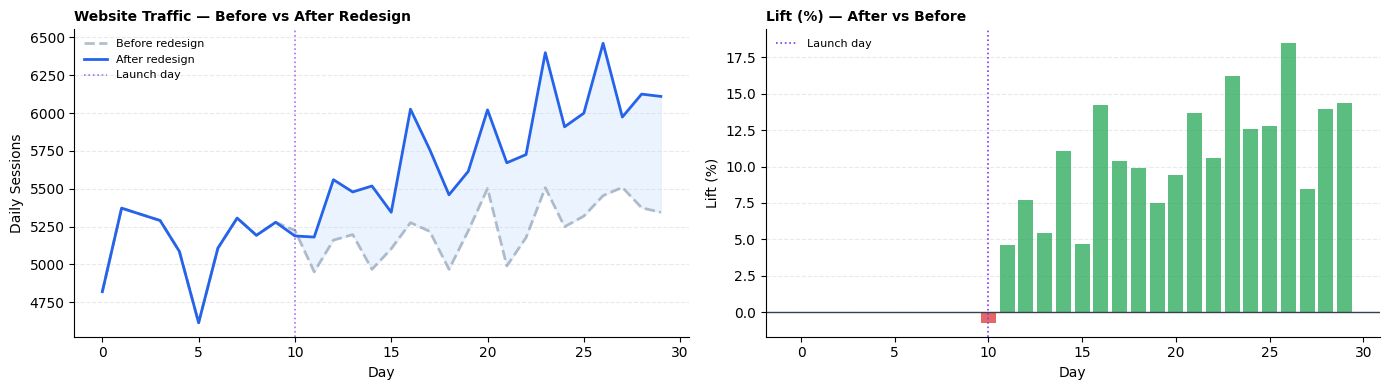

In [8]:
# Simulate: website traffic before and after redesign
T3 = 30
t3 = np.arange(T3)

traffic_before = 5000 + np.random.randn(T3) * 200 + t3 * 10
traffic_after  = traffic_before + np.where(t3 < 10, 0,
                     np.linspace(0, 800, T3)[t3] + np.random.randn(T3) * 150)

fig, axes = plt.subplots(1, 2, figsize=(14, 4), facecolor='white')

# Panel 1: before_after_lines với fill
ax = axes[0]
before_after_lines(
    ax, t3,
    y_before=traffic_before,
    y_after=traffic_after,
    before_color='#94A3B8',
    after_color='#2563EB',
    before_label='Before redesign',
    after_label='After redesign',
    fill=True,
    fill_color='#BFDBFE',
    fill_alpha=0.3,
)
add_reference_line(ax, value=10, orientation='v',
                   color='#7C3AED', linestyle=':', label='Launch day')
ax.set_title('Website Traffic — Before vs After Redesign', loc='left', fontsize=10, fontweight='bold')
ax.set_xlabel('Day'); ax.set_ylabel('Daily Sessions')
ax.legend(frameon=False, fontsize=8)
despine(ax); set_grid(ax)

# Panel 2: lift calculation
ax = axes[1]
lift = (traffic_after - traffic_before) / traffic_before * 100
colors = ['#16A34A' if v >= 0 else '#DC2626' for v in lift]
ax.bar(t3, lift, color=colors, width=0.8, alpha=0.7)
ax.axhline(0, color='#374151', linewidth=1.0)
ax.axvline(10, color='#7C3AED', linewidth=1.2, linestyle=':', label='Launch day')
ax.set_title('Lift (%) — After vs Before', loc='left', fontsize=10, fontweight='bold')
ax.set_xlabel('Day'); ax.set_ylabel('Lift (%)')
ax.legend(frameon=False, fontsize=8)
despine(ax); set_grid(ax)

plt.tight_layout()
plt.show()

## Why This Visualization Is Useful — Before vs After with Lift

Biểu đồ này kết hợp **before/after overlay** và **lift chart**, giúp đọc impact
một cách trực quan hơn so với chỉ plot hai đường riêng biệt.

---

# 1. Thấy ngay direction của impact

Visualization trực tiếp thể hiện:

$$
\Delta_t
=
\text{After}_t
-
\text{Before}_t
$$

- vùng dương → improvement
- vùng âm → decline

Không cần tự ước lượng bằng mắt giữa hai đường.

→ giúp đọc nhanh **redesign tốt hay xấu**

---

# 2. Thấy magnitude của improvement

Lift chart chuẩn hóa theo phần trăm:

$$
\text{Lift}_t
=
\frac{
\text{After}_t
-
\text{Before}_t
}{
\text{Before}_t
}
\times 100\%
$$

Giúp biết:

- tăng bao nhiêu %
- impact có lớn không
- có ý nghĩa business không

→ không chỉ biết **tăng**, mà biết **tăng bao nhiêu**

---

# 3. Thấy duration của impact

Nếu lift dương liên tục:

$$
\text{Lift}_t > 0
\quad \forall t > t_0
$$

→ improvement bền vững

Nếu lift chỉ spike ngắn → effect tạm thời

Visualization giúp phân biệt:

- temporary spike
- sustained improvement

---

# 4. Thấy trend của effect theo thời gian

Nếu:

$$
\frac{d}{dt} \text{Lift}_t > 0
$$

→ impact tăng dần theo thời gian

Điều này rất quan trọng cho:

- redesign
- product change
- model deployment

Vì effect thường **không xuất hiện ngay lập tức**

---

# 5. Tách baseline khỏi effect

Overlay chart cho:

- baseline (before)
- effect (after)

Lift chart cho:

- pure treatment effect

$$
\text{Effect}_t = \text{After}_t - \text{Before}_t
$$

→ loại bỏ seasonal / trend chung

---

# 6. Phát hiện regression dễ dàng

Nếu xuất hiện:

$$
\text{Lift}_t < 0
$$

→ redesign gây hại

Bar chart làm điều này rõ ràng hơn line chart.

---

# 7. Tốt cho storytelling

Visualization này trả lời ngay:

- redesign có giúp không
- giúp bao nhiêu
- giúp khi nào
- giúp bao lâu
- effect có tăng không

Chỉ với **một figure**.

---

# Summary

Before/After + Lift visualization giúp đọc nhanh:

Direction:

$$
\Delta_t = \text{After}_t - \text{Before}_t
$$

Magnitude:

$$
\text{Lift}_t
=
\frac{\Delta_t}{\text{Before}_t}
\times 100\%
$$

Interpretation:

- Lift > 0 → improvement
- Lift < 0 → decline
- Lift tăng dần → growing impact
- Lift ổn định → sustained improvement  

## 6. Relative Performance — Index to Base 100

### Problem with Absolute Comparison

So sánh trực tiếp các series có **mức giá ban đầu khác nhau** dễ gây hiểu nhầm.

Ví dụ:

- Stock A: 200 → 240
- Stock B: 50 → 70

Nhìn absolute:

- A tăng +40
- B tăng +20

Nhưng theo phần trăm:

$$
\text{Return}_A
=
\frac{240 - 200}{200}
=
20\%
$$

$$
\text{Return}_B
=
\frac{70 - 50}{50}
=
40\%
$$

Thực tế **Stock B outperform Stock A**.

---

# Solution — Index to Base 100

Chuẩn hóa tất cả series về cùng điểm bắt đầu:

$$
\text{Index}_t
=
100
\cdot
\frac{x_t}{x_0}
$$

Trong đó:

- $x_t$ : giá trị tại thời điểm $t$
- $x_0$ : giá trị tại thời điểm gốc
- 100 : base index

---

## Interpretation

Sau khi rebase:

| Index | Meaning |
|------|--------|
| 120 | +20% |
| 110 | +10% |
| 100 | no change |
| 90 | −10% |
| 80 | −20% |

Không phụ thuộc vào giá trị ban đầu.

---

## Multiple Series Comparison

Giả sử nhiều assets:

$$
x_t^{(1)},\;
x_t^{(2)},\;
x_t^{(3)}
$$

Rebase:

$$
I_t^{(i)}
=
100
\cdot
\frac{x_t^{(i)}}{x_0^{(i)}}
$$

Sau đó plot:

- tất cả bắt đầu tại 100
- đường cao hơn = outperform
- khoảng cách = relative return gap

---

## Relative Performance

Khoảng cách giữa hai series:

$$
\text{Outperformance}_t
=
I_t^{(A)}
-
I_t^{(B)}
$$

Nếu:

$$
I_t^{(A)} > I_t^{(B)}
$$

→ A outperform B

---

## Example

Original prices:

| Day | A | B |
|----|----|----|
| 0 | 200 | 50 |
| 1 | 210 | 60 |
| 2 | 220 | 65 |

Rebased:

$$
I_t
=
100
\cdot
\frac{x_t}{x_0}
$$

| Day | A | B |
|----|----|----|
| 0 | 100 | 100 |
| 1 | 105 | 120 |
| 2 | 110 | 130 |

→ B outperform rõ ràng

---

## When to Use

Index-to-base phù hợp khi so sánh:

- stocks
- portfolios
- models
- strategies
- traffic growth
- revenue growth
- cumulative returns

---

## Implementation

### Rebase Function

$$
\text{index\_to\_base}(x)
=
100
\cdot
\frac{x}{x_0}
$$

### Relative Performance Chart

- rebase từng series
- plot cùng chart
- legend = asset names
- y-axis = index (base 100)

---

## Interpretation Rules

Higher line → better performance
Crossing lines → leadership change
Distance → performance gap
Slope → growth speed

---

## Summary

Index to base 100 chuyển:

$$
x_t
$$

thành:

$$
100
\cdot
\frac{x_t}{x_0}
$$

Giúp:

- so sánh fair
- đọc outperform
- bỏ bias giá gốc
- trực quan relative growth

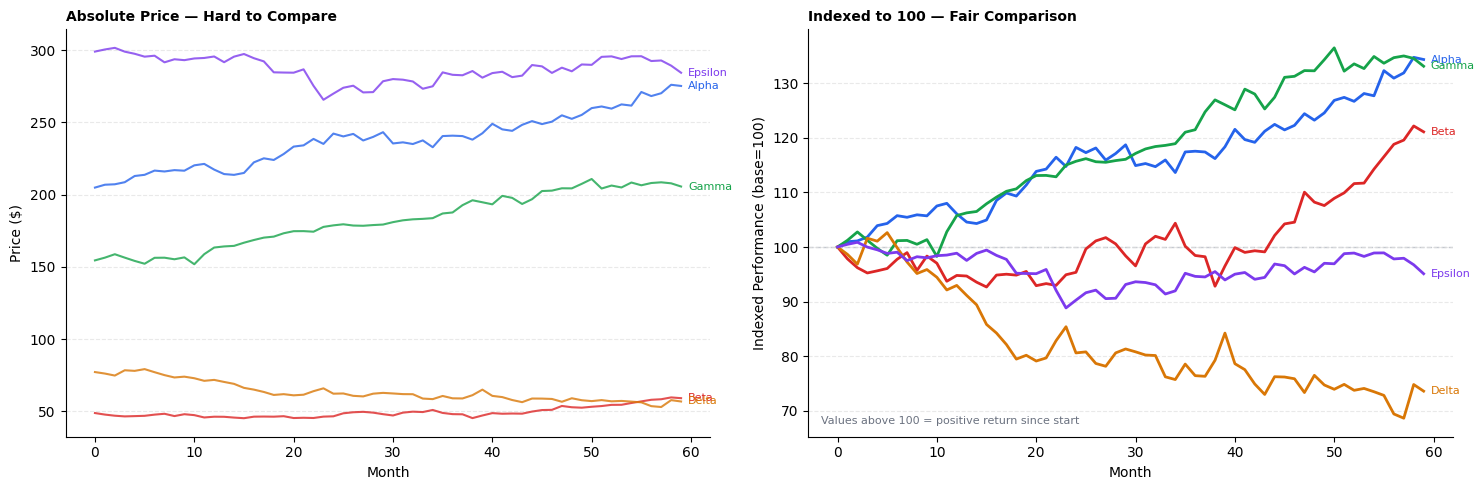

In [9]:
from vizint.comparison.relative import index_to_base

fig, axes = plt.subplots(1, 2, figsize=(15, 5), facecolor='white')

# Panel 1: Absolute prices — hard to compare
ax = axes[0]
abs_prices = {
    'Alpha':   stocks['Alpha'] * 2.0,     # starts at ~$200
    'Beta':    stocks['Beta'] * 0.5,      # starts at ~$50
    'Gamma':   stocks['Gamma'] * 1.5,
    'Delta':   stocks['Delta'] * 0.8,
    'Epsilon': stocks['Epsilon'] * 3.0,
}

colors_stock = ['#2563EB', '#DC2626', '#16A34A', '#D97706', '#7C3AED']
for (name, y), c in zip(abs_prices.items(), colors_stock):
    ax.plot(t2, y, color=c, linewidth=1.5, label=name, alpha=0.8)
    label_last_point(ax, t2, y, text=name, color=c, fontsize=8)

ax.set_title('Absolute Price — Hard to Compare', loc='left', fontsize=10, fontweight='bold')
ax.set_xlabel('Month'); ax.set_ylabel('Price ($)')
despine(ax); set_grid(ax)

# Panel 2: Indexed to 100
ax = axes[1]
relative_performance_chart(
    ax, t2, stocks,
    base_index=0,
    scale=100,
    palette='default',
    linewidth=2.0,
    legend=False,
    reference_line=True,
    reference_color='#9CA3AF',
)
for (name, y), c in zip(stocks.items(), colors_stock):
    indexed = index_to_base(np.asarray(y, float), 0, 100)
    label_last_point(ax, t2, indexed, text=name, color=c, fontsize=8)

ax.set_title('Indexed to 100 — Fair Comparison', loc='left', fontsize=10, fontweight='bold')
ax.set_xlabel('Month'); ax.set_ylabel('Indexed Performance (base=100)')
add_note(ax, 'Values above 100 = positive return since start',
         x=0.02, y=0.05, fontsize=8, color='#6B7280')
despine(ax); set_grid(ax)

plt.tight_layout()
plt.show()

## Relative Performance — Index to Base 100

So sánh trực tiếp **absolute price** dễ gây hiểu nhầm khi các assets có
mức giá ban đầu khác nhau.

Ví dụ:

- Alpha: ~200 → 270
- Beta: ~50 → 60

Nhìn absolute:

- Alpha tăng +70
- Beta tăng +10

Nhưng theo phần trăm:

$$
\text{Return}
=
\frac{x_t - x_0}{x_0}
$$

Beta có thể outperform dù absolute nhỏ hơn.

---

### Solution — Rebase to 100

Chuẩn hóa tất cả series về cùng điểm bắt đầu:

$$
I_t
=
100
\cdot
\frac{x_t}{x_0}
$$

Trong đó:

- $x_t$ : giá trị tại thời điểm $t$
- $x_0$ : giá trị ban đầu
- $I_t$ : indexed performance

---

### Interpretation

Sau khi rebase:

- $I_t > 100$ → tăng so với ban đầu
- $I_t = 100$ → không đổi
- $I_t < 100$ → giảm

Phần trăm return:

$$
\text{Return}_t
=
I_t - 100
$$

---

### Lợi ích của visualization này

#### 1. So sánh công bằng giữa các assets

Sau khi index:

$$
I_t^{(A)} > I_t^{(B)}
$$

→ A outperform B

Không phụ thuộc scale giá ban đầu.

---

#### 2. Nhìn rõ relative growth

Khoảng cách giữa hai đường:

$$
\text{Gap}_t
=
I_t^{(A)} - I_t^{(B)}
$$

→ performance difference

---

#### 3. Phát hiện leader theo thời gian

Nếu hai đường cắt nhau:

$$
I_t^{(A)} = I_t^{(B)}
$$

→ leadership change

---

#### 4. Thấy drawdown dễ hơn

Drawdown từ base:

$$
\text{Drawdown}_t
=
I_t - 100
$$

Assets dưới 100 đang underperform.

---

#### 5. So sánh nhiều assets cùng lúc

Rebase nhiều series:

$$
I_t^{(i)}
=
100
\cdot
\frac{x_t^{(i)}}{x_0^{(i)}}
$$

Tất cả bắt đầu tại 100 → dễ đọc relative performance.

---

### Khi nào nên dùng

Index to base 100 phù hợp khi so sánh:

- stocks
- portfolios
- strategies
- models
- traffic growth
- revenue growth
- cumulative metrics

---

### Summary

Index to base 100 chuyển:

$$
x_t
$$

thành:

$$
I_t
=
100
\cdot
\frac{x_t}{x_0}
$$

Giúp:

- so sánh fair
- loại bỏ scale bias
- đọc outperform dễ
- thấy leadership change
- trực quan relative performance

## 7. Distribution Comparison

Khi so sánh nhiều nhóm, bar chart chỉ hiển thị **mean**:

$$
\mu = \mathbb{E}[X]
$$

Điều này ẩn đi:

- độ phân tán
- skewness
- multimodality
- overlap giữa các nhóm

Hai nhóm có thể có **cùng mean nhưng distribution hoàn toàn khác**.

---

### KDE Overlay — So sánh toàn bộ phân phối

Kernel Density Estimation (KDE) ước lượng mật độ xác suất:

$$
\hat{f}(x)
=
\frac{1}{n h}
\sum_{i=1}^{n}
K
\left(
\frac{x - x_i}{h}
\right)
$$

Trong đó:

- $K$ : kernel function (Gaussian thường dùng)
- $h$ : bandwidth
- $x_i$ : samples

KDE overlay plot nhiều $\hat f(x)$ trên cùng trục.

---

### KDE cho biết những gì

#### 1. Spread (variance)

Distribution rộng hơn:

$$
\sigma^2
=
\mathbb{E}[(X-\mu)^2]
$$

→ nhóm biến động lớn hơn

---

#### 2. Skewness

Distribution lệch:

$$
\text{Skewness}
=
\mathbb{E}
\left[
\left(
\frac{X-\mu}{\sigma}
\right)^3
\right]
$$

→ bias về phía high hoặc low

---

#### 3. Multimodality

Nhiều peaks trong KDE:

$$
\frac{d}{dx} \hat f(x) = 0
\quad \text{multiple solutions}
$$

→ nhiều subgroups

---

#### 4. Overlap giữa hai nhóm

Overlap area:

$$
\text{Overlap}
=
\int
\min
\left(
f_A(x),
f_B(x)
\right)
dx
$$

- overlap lớn → groups similar
- overlap nhỏ → groups separable

---

### Ridge Plot (Joy Plot)

Khi có nhiều groups:

- KDE overlay bị chồng lên nhau
- khó đọc

Ridge plot stack các KDE theo trục dọc:

Group $i$:

$$
y_i(x)
=
\hat f_i(x)
+
c_i
$$

Trong đó $c_i$ là vertical offset.

---

### Lợi ích của ridge plot

#### 1. So sánh nhiều distribution

$$
\hat f_1(x), \hat f_2(x), \dots, \hat f_n(x)
$$

không bị overlap.

---

#### 2. Thấy distribution shift

Nếu peaks dịch chuyển:

$$
\mu_1 < \mu_2 < \mu_3
$$

→ performance tăng theo nhóm

---

#### 3. Thấy spread change

Nếu ridge rộng dần:

$$
\sigma_1 < \sigma_2 < \sigma_3
$$

→ variance tăng

---

#### 4. Phát hiện multimodal theo nhóm

Multiple peaks trong từng ridge:

→ subgroup structure

---

### KDE vs Ridge Plot

KDE overlay:

- tốt cho 2–3 groups
- so sánh trực tiếp overlap
- đọc difference rõ

Ridge plot:

- tốt cho nhiều groups
- tránh overlap
- đọc trend theo nhóm

---

### Khi nên dùng

Distribution comparison phù hợp cho:

- model score comparison
- A/B test distribution
- residual comparison
- latency distribution
- income distribution
- risk distribution
- feature distribution

---

### Summary

Bar chart chỉ cho:

$$
\mu
$$

KDE cho:

$$
f(x)
$$

Ridge plot cho:

$$
f_1(x), f_2(x), \dots, f_n(x)
$$

Giúp:

- so sánh shape
- thấy variance
- phát hiện bimodal
- đo overlap
- đọc distribution shift

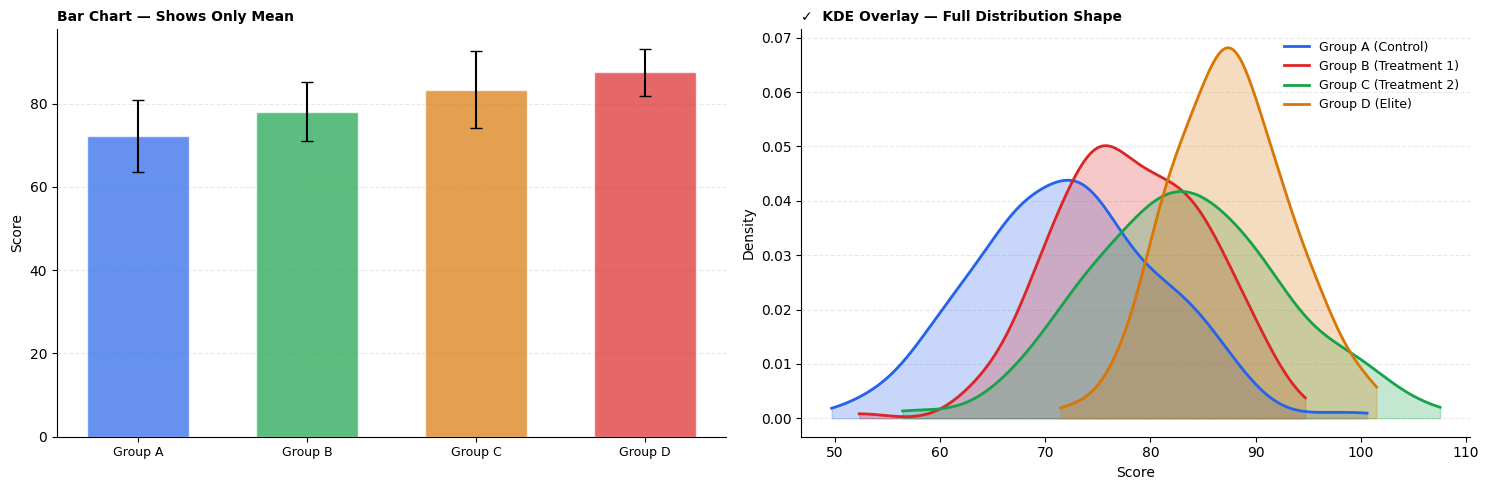

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5), facecolor='white')

# Panel 1: Bar chart — hides distribution shape
ax = axes[0]
means  = [v.mean() for v in score_groups.values()]
stds   = [v.std()  for v in score_groups.values()]
colors_g = ['#2563EB', '#16A34A', '#D97706', '#DC2626']
ax.bar(range(4), means, color=colors_g, alpha=0.7, width=0.6,
       yerr=stds, capsize=4, edgecolor='white')
ax.set_xticks(range(4))
ax.set_xticklabels(['Group A', 'Group B', 'Group C', 'Group D'], fontsize=9)
ax.set_title('Bar Chart — Shows Only Mean', loc='left', fontsize=10, fontweight='bold')
ax.set_ylabel('Score')
despine(ax); set_grid(ax)

# Panel 2: KDE overlay — shows full distribution
ax = axes[1]
compare_distributions(
    ax, score_groups,
    palette='default',
    alpha=0.25,
    linewidth=2.0,
    legend=True,
)
ax.set_title('✓  KDE Overlay — Full Distribution Shape', loc='left', fontsize=10, fontweight='bold')
ax.set_xlabel('Score')
ax.set_ylabel('Density')
despine(ax); set_grid(ax)

plt.tight_layout()
plt.show()

## Distribution Comparison

Bar chart chỉ hiển thị **mean** của mỗi nhóm:

$$
\mu
=
\mathbb{E}[X]
$$

Điều này ẩn đi toàn bộ shape của distribution.
Hai nhóm có thể có cùng mean nhưng **spread hoàn toàn khác**.

---

### Vấn đề với Bar Chart

Bar chart chỉ cho:

$$
\mu_A, \mu_B, \mu_C, \mu_D
$$

Nhưng không cho biết:

- variance khác nhau?
- distribution lệch trái / phải?
- có nhiều peaks?
- overlap giữa groups?
- risk tail?

Do đó bar chart **không đủ để so sánh performance thực sự**.

---

## KDE Overlay — Full Distribution Shape

KDE ước lượng mật độ xác suất:

$$
\hat f(x)
=
\frac{1}{nh}
\sum_{i=1}^{n}
K
\left(
\frac{x-x_i}{h}
\right)
$$

Plot nhiều KDE:

$$
\hat f_A(x),
\hat f_B(x),
\hat f_C(x),
\hat f_D(x)
$$

→ thấy toàn bộ distribution.

---

### Lợi ích của KDE overlay

#### 1. So sánh spread

Variance:

$$
\sigma^2
=
\mathbb{E}
[(X-\mu)^2]
$$

Distribution rộng hơn → variance lớn hơn → risk cao hơn.

---

#### 2. So sánh skew

Skewness:

$$
\text{Skew}
=
\mathbb{E}
\left[
\left(
\frac{X-\mu}{\sigma}
\right)^3
\right]
$$

→ distribution lệch trái hoặc phải.

---

#### 3. Phát hiện bimodal

Nếu KDE có nhiều peaks:

$$
\frac{d}{dx}\hat f(x)=0
\quad \text{multiple peaks}
$$

→ tồn tại subgroups.

---

#### 4. So sánh overlap

Overlap giữa hai nhóm:

$$
\text{Overlap}
=
\int
\min
(
f_A(x),
f_B(x)
)
dx
$$

- overlap lớn → groups similar
- overlap nhỏ → groups khác biệt rõ

---

#### 5. So sánh dominance

Nếu:

$$
f_D(x)
\text{ shift sang phải}
$$

→ Group D có score cao hơn toàn bộ distribution.

---

## Interpretation từ hình

- Group A: mean thấp, spread rộng
- Group B: shift sang phải so với A
- Group C: mean cao hơn, variance lớn
- Group D: distribution cao nhất, ít overlap

Bar chart chỉ cho:

$$
\mu_A < \mu_B < \mu_C < \mu_D
$$

KDE cho thêm:

- spread khác nhau
- overlap giữa nhóm
- risk tail
- dominance thật sự

---

## Khi nên dùng KDE thay bar chart

So sánh:

- model scores
- exam scores
- latency
- revenue per user
- prediction distribution
- risk distribution
- A/B testing

---

## Summary

Bar chart chỉ hiển thị:

$$
\mu
$$

KDE hiển thị:

$$
f(x)
$$

Giúp:

- thấy spread
- thấy skew
- thấy bimodal
- thấy overlap
- so sánh distribution thật

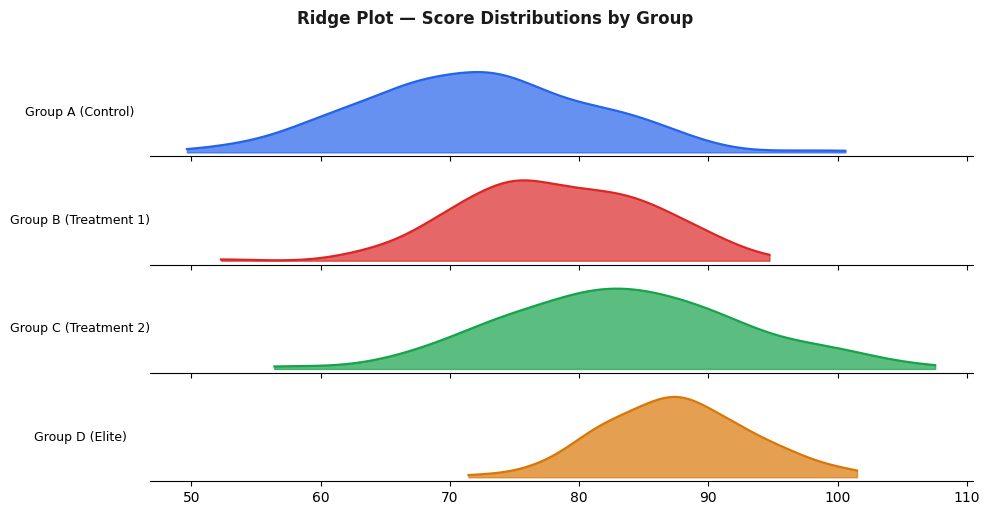

In [11]:
# Ridge plot — tốt cho nhiều nhóm (tránh clutter)
fig = ridge_plot(
    score_groups,
    overlap=0.5,
    palette='default',
    figsize=(10, 5),
)
fig.suptitle('Ridge Plot — Score Distributions by Group',
             fontsize=12, fontweight='bold', color='#1a1a1a', y=1.02)
plt.tight_layout()
plt.show()

## Ridge Plot — Comparing Multiple Distributions

Khi có nhiều nhóm, KDE overlay bị chồng lên nhau và khó đọc.
Ridge plot giải quyết bằng cách **stack các distribution theo trục dọc**.

Mỗi nhóm có một KDE riêng, dịch lên theo offset:

$$
y_i(x)
=
\hat f_i(x)
+
c_i
$$

Trong đó:

- $\hat f_i(x)$ : KDE của nhóm $i$
- $c_i$ : vertical offset
- $y_i(x)$ : ridge curve

---

### Lợi ích của Ridge Plot

#### 1. So sánh nhiều distribution cùng lúc

Ridge plot hiển thị:

$$
\hat f_1(x),
\hat f_2(x),
\hat f_3(x),
\hat f_4(x)
$$

không bị overlap như KDE overlay.

→ dễ đọc khi có nhiều nhóm

---

#### 2. Thấy distribution shift

Nếu peaks dịch chuyển sang phải:

$$
\mu_A < \mu_B < \mu_C < \mu_D
$$

→ performance tăng dần theo nhóm

Ridge plot làm điều này rất rõ ràng.

---

#### 3. So sánh spread giữa nhóm

Variance:

$$
\sigma_i^2
=
\mathbb{E}[(X_i-\mu_i)^2]
$$

Distribution rộng hơn → variance lớn hơn.

Ridge plot giúp so sánh width của từng nhóm.

---

#### 4. Phát hiện overlap giữa nhóm

Overlap:

$$
\text{Overlap}_{ij}
=
\int
\min
(
f_i(x),
f_j(x)
)
dx
$$

Nếu ridge gần nhau → groups similar
Nếu ridge tách biệt → groups clearly different

---

#### 5. Thấy progression theo nhóm

Nếu groups có thứ tự (Control → Treatment → Elite):

$$
\mu_1 < \mu_2 < \mu_3 < \mu_4
$$

Ridge plot thể hiện **distribution shift theo thứ tự**.

---

### Interpretation từ hình

- Group A: distribution thấp nhất
- Group B: shift sang phải so với A
- Group C: tiếp tục shift phải
- Group D: highest scores

Thể hiện:

$$
\mu_A < \mu_B < \mu_C < \mu_D
$$

Ngoài ra:

- Group A spread rộng hơn
- Group D concentrated hơn
- overlap giảm dần theo nhóm

---

### Khi nên dùng Ridge Plot

Ridge plot phù hợp khi so sánh:

- nhiều models
- nhiều experiments
- nhiều cohorts
- nhiều time periods
- nhiều segments
- score distributions

---

### Ridge vs KDE Overlay

KDE overlay:

- tốt cho 2–3 groups
- so sánh overlap trực tiếp

Ridge plot:

- tốt cho nhiều groups
- tránh clutter
- dễ đọc progression

---

### Summary

Ridge plot hiển thị:

$$
y_i(x)
=
\hat f_i(x) + c_i
$$

Giúp:

- so sánh nhiều distributions
- thấy shift giữa nhóm
- so sánh variance
- phát hiện overlap
- đọc progression dễ dàng

## 8. Small Multiples (Faceted Grid)

Small multiples = lặp lại **cùng một chart type** cho nhiều nhóm hoặc entities,
mỗi nhóm một panel riêng.

Thay vì overlay nhiều series trên cùng một trục:

$$
y^{(1)}(t),\;
y^{(2)}(t),\;
y^{(3)}(t)
$$

Small multiples tách thành:

- Panel 1: $y^{(1)}(t)$
- Panel 2: $y^{(2)}(t)$
- Panel 3: $y^{(3)}(t)$

Giúp so sánh pattern trực quan hơn.

---

### Vì sao small multiples hiệu quả

#### 1. Tránh overlap

Overlay nhiều series:

$$
y^{(1)}(t) + y^{(2)}(t) + \dots
$$

→ clutter

Small multiples tách riêng từng series:

$$
\text{Panel}_i = y^{(i)}(t)
$$

→ clean hơn

---

#### 2. So sánh shape dễ hơn

Mắt người so sánh **shape** tốt hơn **màu sắc**.

So sánh:

- slope
- peaks
- volatility
- turning points

dễ hơn khi mỗi panel riêng.

---

#### 3. Hỗ trợ scale khác nhau

Nếu mỗi nhóm có scale khác:

$$
y_A \in [0, 10]
$$

$$
y_B \in [0, 1000]
$$

Overlay sẽ làm nhóm nhỏ bị "flatten".

Small multiples cho phép:

- y-axis riêng cho mỗi panel
- đọc pattern chính xác hơn

---

#### 4. So sánh trend giữa nhóm

So sánh tốc độ thay đổi:

$$
\frac{d}{dt} y_i(t)
$$

Small multiples giúp nhìn:

- nhóm nào tăng nhanh hơn
- nhóm nào biến động mạnh hơn
- nhóm nào có seasonality

---

#### 5. So sánh turning points

Turning point:

$$
\frac{d}{dt} y(t) = 0
$$

Small multiples giúp thấy:

- peak xảy ra cùng lúc không
- lag giữa groups
- regime change

---

### Khi nên dùng small multiples

Small multiples phù hợp khi:

- nhiều time series
- nhiều regions
- nhiều products
- nhiều models
- nhiều experiments
- nhiều cohorts

---

### So sánh với overlay

Overlay:

$$
y^{(1)}(t), y^{(2)}(t), y^{(3)}(t)
$$

- tốt khi ít series
- so sánh trực tiếp
- nhưng dễ clutter

Small multiples:

$$
\text{Panel}_i = y^{(i)}(t)
$$

- tốt khi nhiều series
- dễ đọc pattern
- không overlap

---

### Summary

Small multiples tách:

$$
y^{(1)}(t), \dots, y^{(n)}(t)
$$

thành:

$$
\text{Panel}_1,\;
\text{Panel}_2,\;
\dots,\;
\text{Panel}_n
$$

Giúp:

- tránh overlap
- so sánh shape dễ
- hỗ trợ scale khác nhau
- đọc pattern rõ hơn

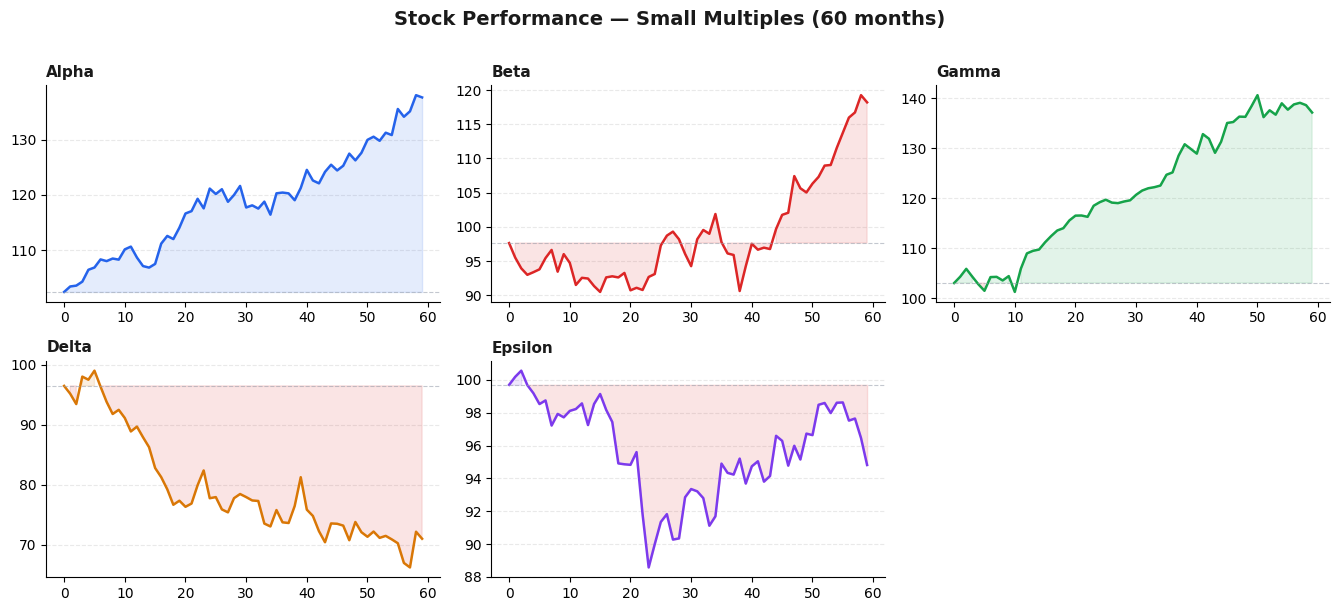

In [12]:
# Prepare panel data: mỗi stock là một panel
panels = {name: (t2, y) for name, y in stocks.items()}

def stock_panel_fn(ax, x, y, color):
    """Custom plot function cho mỗi panel."""
    ax.plot(x, y, color=color, linewidth=1.8)
    ax.axhline(y[0], color='#9CA3AF', linewidth=0.8, linestyle='--', alpha=0.6)
    # Fill above/below starting price
    ax.fill_between(x, y, y[0],
                    where=(y >= y[0]), color=color, alpha=0.12)
    ax.fill_between(x, y, y[0],
                    where=(y < y[0]), color='#DC2626', alpha=0.12)

fig = small_multiples(
    groups=panels,
    plot_fn=stock_panel_fn,
    ncols=3,
    figsize_per_panel=(4.5, 3.0),
    shared_y=False,
    title_fontsize=11,
    palette='default',
    suptitle='Stock Performance — Small Multiples (60 months)',
    despine_panels=True,
    grid_panels=True,
)
plt.tight_layout()
plt.show()

## Small Multiples — Comparing Stock Performance

Small multiples hiển thị mỗi stock trong một panel riêng, giúp so sánh
**pattern**, **trend**, và **volatility** mà không bị overlap.

Mỗi panel biểu diễn:

$$
y_i(t)
$$

với $i$ là từng stock.

---

### Lợi ích của visualization này

#### 1. So sánh trend rõ ràng

So sánh slope:

$$
\frac{d}{dt} y_i(t)
$$

Từ hình:

- Alpha: trend tăng ổn định
- Beta: sideway → tăng mạnh cuối kỳ
- Gamma: tăng mạnh nhất
- Delta: giảm liên tục
- Epsilon: giảm rồi hồi phục

Small multiples giúp đọc trend từng nhóm rõ ràng.

---

#### 2. So sánh volatility

Volatility:

$$
\sigma_i
=
\text{std}(y_i)
$$

Nhìn width và zig-zag:

- Beta: volatility cao
- Delta: volatility trung bình nhưng downtrend
- Alpha: volatility thấp hơn
- Gamma: trend mạnh + volatility vừa

---

#### 3. So sánh performance direction

So sánh tổng return:

$$
R_i
=
\frac{y_i(T) - y_i(0)}{y_i(0)}
$$

Từ hình:

- Gamma: best performance
- Alpha: strong growth
- Beta: late recovery
- Epsilon: near flat
- Delta: negative performance

---

#### 4. Phát hiện regime change

Turning point:

$$
\frac{d}{dt} y_i(t) = 0
$$

Nhìn thấy:

- Beta: regime change giữa kỳ
- Epsilon: bottom rồi recovery
- Delta: persistent downtrend

---

#### 5. So sánh shape dễ hơn overlay

Overlay nhiều series:

$$
y_1(t), y_2(t), \dots, y_n(t)
$$

→ khó phân biệt

Small multiples:

$$
\text{Panel}_i = y_i(t)
$$

→ mỗi shape rõ ràng.

---

### Interpretation Summary

- Gamma outperform toàn bộ
- Alpha tăng ổn định
- Beta hồi phục mạnh cuối kỳ
- Epsilon giảm rồi hồi phục nhẹ
- Delta underperform mạnh

Small multiples giúp:

- so sánh trend
- so sánh volatility
- phát hiện regime change
- đọc performance từng nhóm rõ ràng

## 9. Putting It All Together — Context Stack

Context stack kết hợp nhiều lớp **reference** trong cùng một chart để tăng
khả năng diễn giải.

Một time series cơ bản:

$$
x_t
$$

được đặt trong nhiều lớp context:

- benchmark band
- target line
- excess / deficit shading
- mean reference
- event markers

Giúp chart trả lời nhiều câu hỏi cùng lúc.

---

### 1. Benchmark Band — vùng tham chiếu

Benchmark band xác định vùng chấp nhận:

$$
L \le x_t \le U
$$

Trong đó:

- $L$ : lower bound
- $U$ : upper bound

Nếu:

$$
x_t > U
$$

→ outperform

Nếu:

$$
x_t < L
$$

→ underperform

---

### 2. Target Line — mục tiêu

Target:

$$
T
$$

Khoảng cách tới target:

$$
\Delta_t
=
x_t - T
$$

- $\Delta_t > 0$ → vượt target
- $\Delta_t < 0$ → dưới target

---

### 3. Excess / Deficit Shading

Excess:

$$
\text{Excess}_t
=
\max(x_t - T, 0)
$$

Deficit:

$$
\text{Deficit}_t
=
\max(T - x_t, 0)
$$

Shading thể hiện magnitude deviation.

---

### 4. Mean Reference — baseline trung bình

Mean:

$$
\mu
=
\mathbb{E}[x_t]
$$

Deviation from mean:

$$
x_t - \mu
$$

Giúp thấy:

- regime shift
- sustained improvement
- sustained decline

---

### 5. Event Markers — mốc sự kiện

Event tại thời điểm $t_e$:

$$
t = t_e
$$

So sánh trước / sau event:

$$
x_{t>t_e} - x_{t<t_e}
$$

Giúp đánh giá impact.

---

### Context Stack hoàn chỉnh

Chart chứa:

$$
x_t
$$

với các reference:

- benchmark band: $[L,U]$
- target: $T$
- mean: $\mu$
- events: $t_e$

Deviation:

$$
x_t - T
$$

$$
x_t - \mu
$$

$$
x_t \notin [L,U]
$$

---

### Lợi ích của context stack

#### 1. Không cần nhiều chart

Một chart trả lời:

- có đạt target không
- có vượt benchmark không
- có tốt hơn mean không
- event có impact không

---

#### 2. Đọc deviation trực quan

Deviation:

$$
x_t - T
$$

được thể hiện bằng shading.

---

#### 3. So sánh nhiều reference cùng lúc

So sánh:

$$
x_t \quad vs \quad T, \mu, [L,U]
$$

Giúp hiểu performance toàn diện.

---

#### 4. Tăng narrative power

Chart thể hiện:

- baseline
- target
- performance
- deviation
- event impact

Trong một visualization.

---

### Khi nên dùng context stack

Phù hợp cho:

- KPI tracking
- model monitoring
- trading performance
- A/B experiment
- operational metrics
- anomaly detection

---

### Summary

Context stack đặt:

$$
x_t
$$

trong nhiều lớp:

- benchmark: $[L,U]$
- target: $T$
- mean: $\mu$
- event: $t_e$

Deviation:

$$
x_t - T
$$

$$
x_t - \mu
$$

Giúp:

- đọc performance nhanh
- hiểu context đầy đủ
- tăng khả năng storytelling

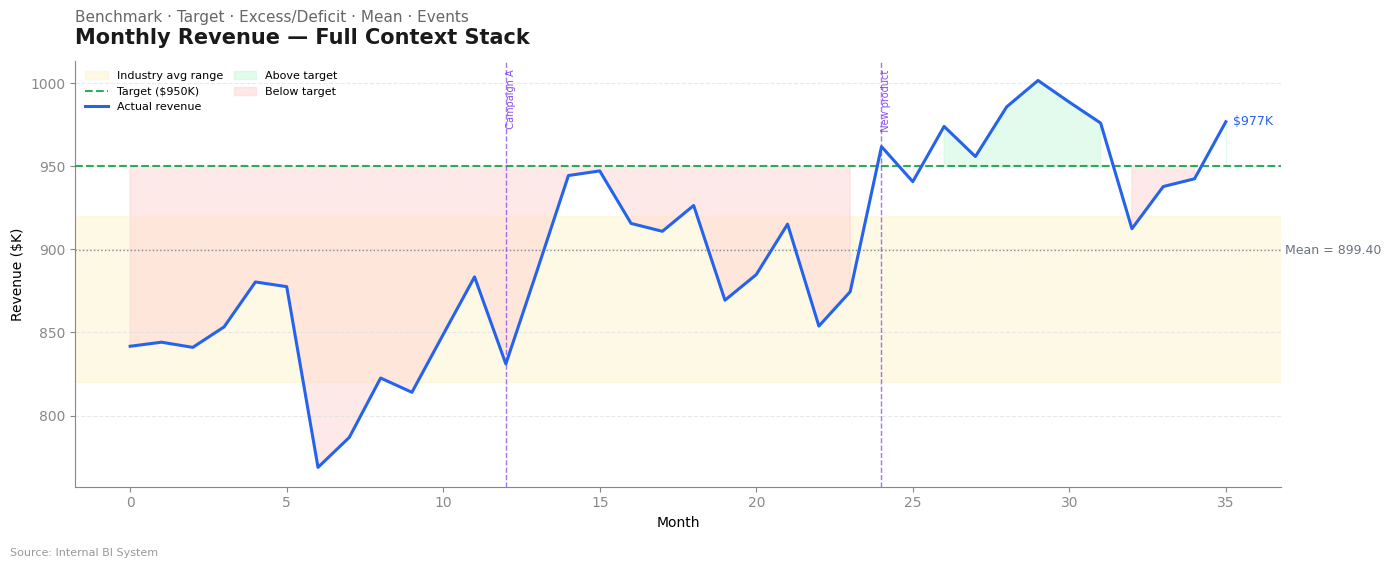

In [13]:
from vizint.narrative import add_event_markers
from vizint.annotation import annotate_with_arrow

chart = (
    ChartBuilder(figsize=(14, 5.5))
    .set_title('Monthly Revenue — Full Context Stack')
    .set_subtitle('Benchmark · Target · Excess/Deficit · Mean · Events')
    .set_source('Internal BI System')
    .build()
)
ax = chart.ax

# Layer 1: Benchmark band (industry range)
add_benchmark_band(ax, BENCHMARK_LOW, BENCHMARK_HIGH,
                   color='#FEF3C7', alpha=0.45,
                   label='Industry avg range')

# Layer 2: Target line
add_target_line(ax, TARGET, color='#16A34A', linewidth=1.5,
                linestyle='--', label=f'Target (${TARGET}K)')

# Layer 3: Actual series
ax.plot(months, revenue, color='#2563EB', linewidth=2.2,
        label='Actual revenue', zorder=4)

# Layer 4: Excess/deficit vs target
shade_excess(ax, months, revenue, baseline=TARGET,
             color='#BBF7D0', alpha=0.4, label='Above target')
shade_deficit(ax, months, revenue, baseline=TARGET,
              color='#FECACA', alpha=0.4, label='Below target')

# Layer 5: Mean reference
add_mean_line(ax, revenue, color='#6B7280', show_label=True,
              linewidth=1.0, linestyle=':')

# Layer 6: Event markers
add_event_markers(ax, [12, 24], labels=['Campaign A', 'New product'],
                  color='#7C3AED', linewidth=1.0, label_fontsize=7)

# Label last point
label_last_point(ax, months, revenue,
                 text=f'${revenue[-1]:.0f}K', color='#2563EB')

ax.set_xlabel('Month')
ax.set_ylabel('Revenue ($K)')
ax.legend(frameon=False, fontsize=8, loc='upper left',
          ncol=2, columnspacing=1.0)

plt.tight_layout()
plt.show()

## Context Stack — Interpreting Full Context Chart

Context stack đặt series chính:

$$
x_t
$$

trong nhiều lớp reference cùng lúc:

- benchmark band
- target line
- mean reference
- excess / deficit shading
- event markers

Giúp đọc performance trong **đầy đủ bối cảnh**.

---

### 1. So sánh với Target

Target:

$$
T = 950
$$

Deviation:

$$
\Delta_t = x_t - T
$$

- $\Delta_t > 0$ → vượt target
- $\Delta_t < 0$ → dưới target

Từ chart:

- giai đoạn đầu mostly dưới target
- sau event thứ hai vượt target thường xuyên
- cuối kỳ duy trì above target

→ performance cải thiện theo thời gian

---

### 2. So sánh với Benchmark Band

Benchmark:

$$
L \le x_t \le U
$$

với:

- $L \approx 820$
- $U \approx 920$

Interpretation:

- trong band → normal performance
- trên band → outperform industry
- dưới band → underperform

Từ chart:

- đầu kỳ trong band
- giữa kỳ dao động
- cuối kỳ nhiều điểm **trên band**

→ revenue vượt benchmark về cuối kỳ

---

### 3. So sánh với Mean

Mean:

$$
\mu \approx 899
$$

Deviation from mean:

$$
x_t - \mu
$$

Interpretation:

- trước month ~15: mostly dưới mean
- sau month ~24: mostly trên mean

→ regime shift upward

---

### 4. Excess / Deficit Visualization

Excess:

$$
\max(x_t - T, 0)
$$

Deficit:

$$
\max(T - x_t, 0)
$$

Chart shading:

- xanh → excess
- đỏ → deficit

Cho thấy:

- deficit lớn đầu kỳ
- excess tăng dần
- cuối kỳ mostly excess

---

### 5. Event Impact

Events tại:

$$
t = t_1, t_2
$$

So sánh trước / sau:

$$
x_{t>t_e} - x_{t<t_e}
$$

Từ chart:

Event 1:

- dip ngắn hạn
- recovery sau đó

Event 2:

- shift lên mức cao hơn
- nhiều điểm vượt target

→ event 2 tạo structural improvement

---

### 6. Narrative từ Context Stack

Chart cho thấy:

- đầu kỳ: dưới target
- giữa kỳ: dao động quanh benchmark
- sau event 2: vượt target thường xuyên
- cuối kỳ: sustained above target

Context stack giúp thấy cùng lúc:

- target achievement
- benchmark comparison
- mean shift
- event impact
- deviation magnitude

---

### Summary

Chart kết hợp:

$$
x_t
$$

với:

- target: $T$
- benchmark: $[L,U]$
- mean: $\mu$
- events: $t_e$

Cho phép đọc:

$$
x_t - T
$$

$$
x_t - \mu
$$

$$
x_t \notin [L,U]
$$

Trong **một visualization duy nhất**.

---
## Summary

| Technique | Function | Context được inject |
|-----------|----------|--------------------|
| Mean reference | `add_mean_line` | Trung bình của chính data |
| Median reference | `add_median_line` | Median — robust vs outlier |
| Custom reference | `add_reference_line` | Bất kỳ threshold, h hoặc v |
| Target line | `add_target_line` | KPI / quota |
| Target zone | `add_target_zone` | Acceptable range |
| Benchmark band | `add_benchmark_band` | Industry / peer range |
| Shade above/below | `shade_above/below_benchmark` | Tô rõ hit vs miss |
| Excess / deficit | `shade_excess` / `shade_deficit` | Delta vs baseline |
| Before/after | `before_after_lines` | Treatment / policy effect |
| Relative perf | `relative_performance_chart` | Fair comparison base=100 |
| KDE overlay | `compare_distributions` | Full distribution shape |
| Ridge plot | `ridge_plot` | Multi-group distribution |
| Small multiples | `small_multiples` | Faceted comparison grid |

---

### Key Takeaway

> Một số liệu không tự nói lên ý nghĩa của nó.
> Ý nghĩa chỉ xuất hiện khi có **điểm tham chiếu** — target, benchmark, baseline, hay competitor.
> Nhiệm vụ của chart là nhúng điểm tham chiếu đó trực tiếp vào trong hình ảnh.

**Next →** `04_uncertainty_visualization.ipynb` — Mọi dự báo đều có sai số. Cách hiển thị uncertainty một cách trung thực.